# Data Loading, Merging & Deep Exploration


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data/train.csv")

In [3]:
display(df.head())

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
df.shape

(9800, 18)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [6]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [7]:
df.describe(include="object")

,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name
count,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800
unique,4922,1230,1326,4,793,793,3,1,529,49,4,1861,3,17,1849
top,CA-2018-100111,05/09/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,38,34,5859,35,35,5101,9800,891,1946,3140,19,5909,1492,47


### check for missing values

In [8]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "column":missing.index,
    "values":missing.values,
    "percentage_missing_onoverall_data:":(missing.values/len(df))*100
})

In [9]:
missing_df ### on Overall data there are 0.112245 % missing data 

,column,values,percentage_missing_onoverall_data:
0,Row ID,0,0.000000
1,Order ID,0,0.000000
2,Order Date,0,0.000000
3,Ship Date,0,0.000000
4,Ship Mode,0,0.000000
5,Customer ID,0,0.000000
6,Customer Name,0,0.000000
7,Segment,0,0.000000
8,Country,0,0.000000
9,City,0,0.000000


In [10]:
### remove missing values in postal code as i think it wont more valuable in forcasting , later i will remove this unnecessary feature
df = df.dropna(subset=["Postal Code"])

In [11]:
df.shape

(9789, 18)

In [12]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
dtype: int64

### checking duplicate values

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
## No as Such duplicates values in the data set

### convert the dates into pd date time 

In [15]:
df["Order Date"] ## it is in day-month-year format but pd expects month-day-year format

0       08/11/2017
1       08/11/2017
2       12/06/2017
3       11/10/2016
4       11/10/2016
           ...    
9795    21/05/2017
9796    12/01/2016
9797    12/01/2016
9798    12/01/2016
9799    12/01/2016
Name: Order Date, Length: 9789, dtype: object

In [16]:
df["Order Date"] = pd.to_datetime(df["Order Date"],dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"],dayfirst=True)

In [17]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
dtype: object

### Extract time features: Year, Month, Week Number, Day of Week, Quarter, Season

In [18]:
# Year
df["Year"] = df["Order Date"].dt.year
## month
df["Month"] = df["Order Date"].dt.month
## Month Name
df["Month_Name"] = df["Order Date"].dt.month_name()
## Week Number
df["Week_Number"] = df["Order Date"].dt.isocalendar().week.astype(int)
## Which day in the week
df["Day_of_Week"] = df["Order Date"].dt.day_name()
# Quarter
df["Quarter"] = df["Order Date"].dt.quarter

In [19]:
df.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Year,Month,Month_Name,Week_Number,Day_of_Week,Quarter
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2017,11,November,45,Wednesday,4
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,2017,11,November,45,Wednesday,4


### Get season Feature

In [20]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(get_season)

In [21]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Year', 'Month', 'Month_Name', 'Week_Number',
       'Day_of_Week', 'Quarter', 'Season'],
      dtype='object')

In [22]:
df.head(1)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Year,Month,Month_Name,Week_Number,Day_of_Week,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.96,2017,11,November,45,Wednesday,4,Autumn


In [23]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Year                      int32
Month                     int32
Month_Name               object
Week_Number               int64
Day_of_Week              object
Quarter                   int32
Season                   object
dtype: object

In [24]:
### convert shipping time in days

In [25]:
# Shipping Time (in days)
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

In [26]:
df.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Year,Month,Month_Name,Week_Number,Day_of_Week,Quarter,Season,Shipping Days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.96,2017,11,November,45,Wednesday,4,Autumn,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,2017,11,November,45,Wednesday,4,Autumn,3


### Aggregate daily sales into weekly and monthly totals (you will need both granularities for different models)


In [27]:
## Daily sales
daily_sales = (
    df.groupby("Order Date")["Sales"]
      .sum()
      .reset_index()
)

daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [31]:
## Highest daily sale
daily_sales.loc[monthly_sales["Sales"].idxmax()]

Order Date    2015-03-07 00:00:00
Sales                    1561.062
Name: 46, dtype: object

In [32]:
## Weekly sales 
weekly_sales = (
    df.set_index("Order Date")
      .resample("W")["Sales"]
      .sum()
      .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [33]:
## highest week sale
weekly_sales.loc[monthly_sales["Sales"].idxmax()]

Order Date    2015-11-22 00:00:00
Sales                  26793.6235
Name: 46, dtype: object

In [29]:
## Monthly sales
monthly_sales = (
    df.set_index("Order Date")
      .resample("ME")["Sales"]
      .sum()
      .reset_index()
)

monthly_sales.head(10)

,Order Date,Sales
0,2015-01-31,14205.7070
1,2015-02-28,4519.8920
2,2015-03-31,55205.7970
3,2015-04-30,27906.8550
4,2015-05-31,23644.3030
5,2015-06-30,34322.9356
6,2015-07-31,33781.5430
7,2015-08-31,27117.5365
8,2015-09-30,81623.5268
9,2015-10-31,31453.3930


In [34]:
monthly_sales["Sales"].max()

117938.155

In [35]:
## in which month sales rate is high
monthly_sales.loc[monthly_sales["Sales"].idxmax()]

Order Date    2018-11-30 00:00:00
Sales                  117938.155
Name: 46, dtype: object

In [36]:
## check daily weekly monthly sales shape
print("Daily Sales Shape:",daily_sales.shape)
print("Weekly Sales Shape:",weekly_sales.shape)
print("Monthly Sales Shape:",monthly_sales.shape)

Daily Sales Shape: (1229, 2)
Weekly Sales Shape: (209, 2)
Monthly Sales Shape: (48, 2)


### Visualize the sales data 

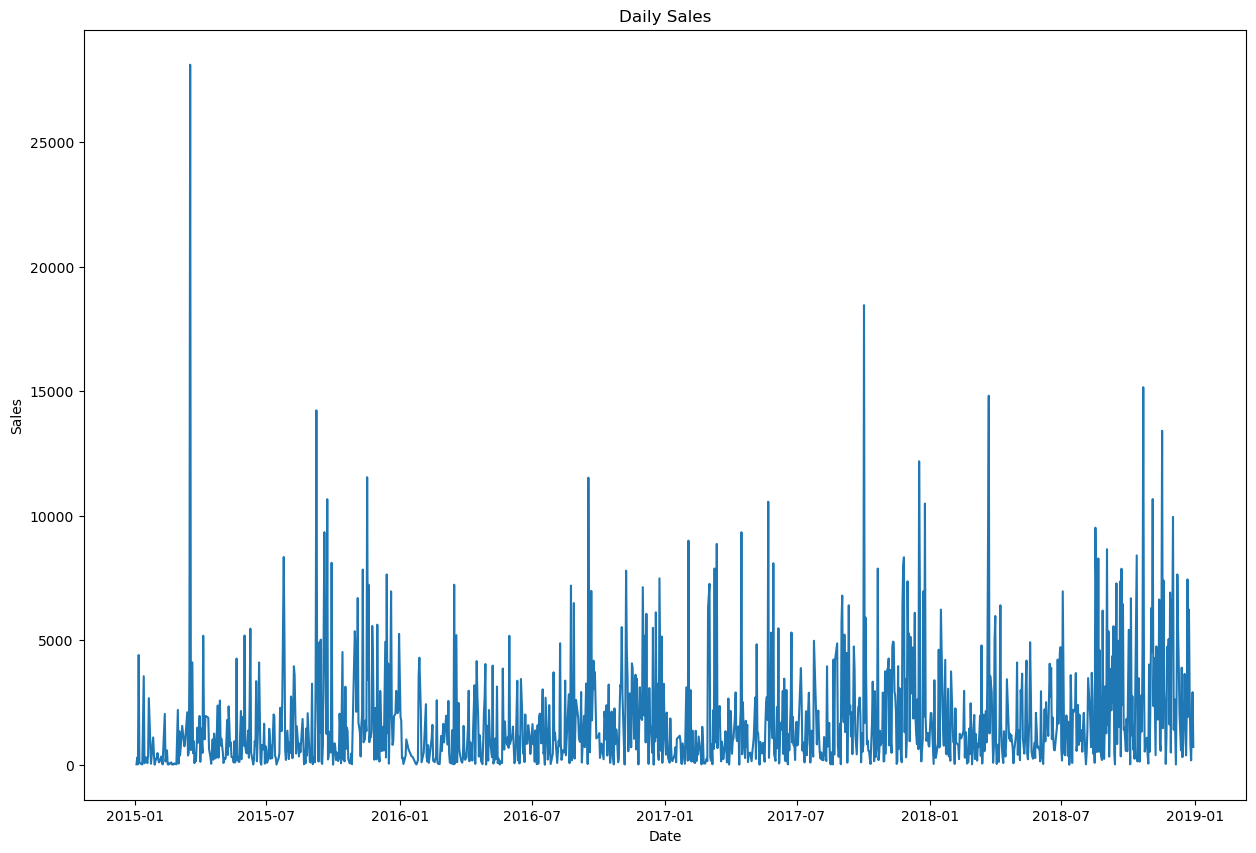

In [37]:
## Daily 

plt.figure(figsize=(15,10))
plt.plot(daily_sales["Order Date"], daily_sales["Sales"])

plt.title("Daily Sales")

plt.xlabel("Date")

plt.ylabel("Sales")
# plt.savefig("charts/daily_sales.png",dpi=300, bbox_inches="tight")
plt.show()

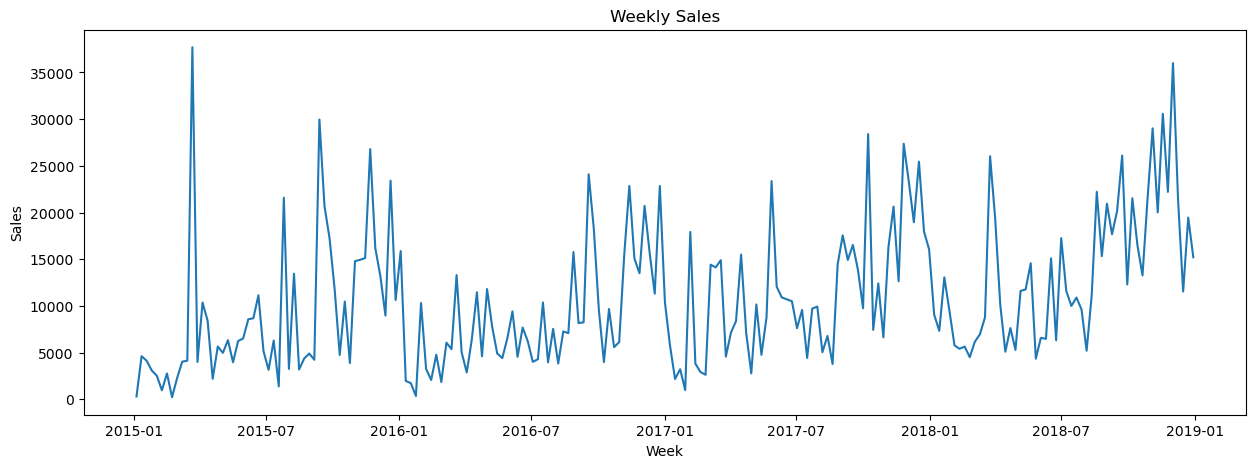

In [38]:
## weekly sales 
plt.figure(figsize=(15,5))

plt.plot(weekly_sales["Order Date"], weekly_sales["Sales"])

plt.title("Weekly Sales")

plt.xlabel("Week")

plt.ylabel("Sales")
# plt.savefig("charts/weekly_sales.png",dpi=300, bbox_inches="tight")
plt.show()

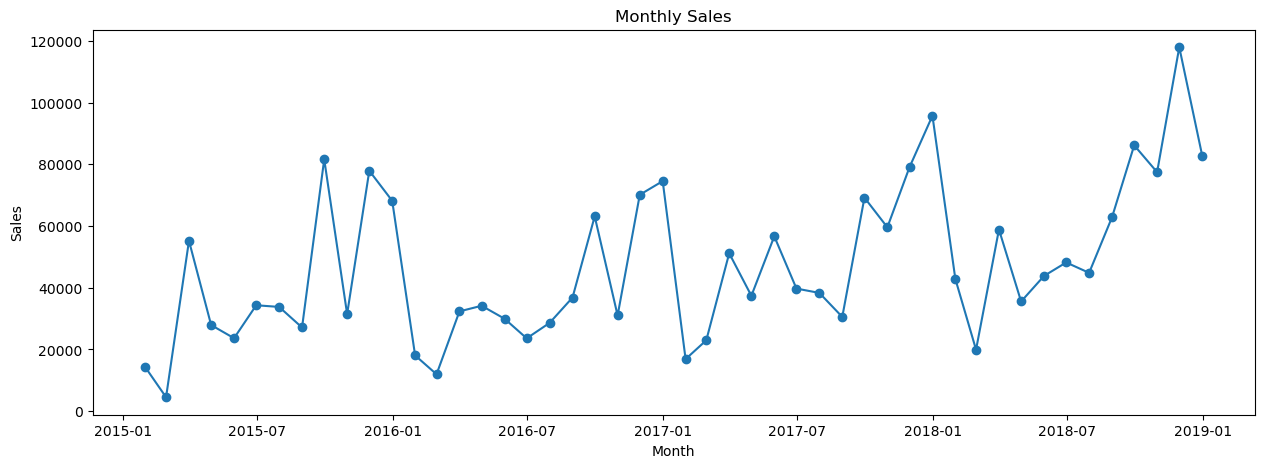

In [39]:
## monthly sales
plt.figure(figsize=(15,5))

plt.plot(monthly_sales["Order Date"], monthly_sales["Sales"], marker="o")

plt.title("Monthly Sales")

plt.xlabel("Month")

plt.ylabel("Sales")
# plt.savefig("charts/monthly_sales.png",dpi=300, bbox_inches="tight")
plt.show()

In [40]:
# weekly_sales.to_csv("Aggrigate_sales_data/weekly_sales.csv", index=False)
# monthly_sales.to_csv("Aggrigate_sales_data/monthly_sales.csv", index=False)
# daily_sales.to_csv("Aggrigate_sales_data/daily_sales.csv", index=False)

### Business Insights

In [41]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Year,Month,Month_Name,Week_Number,Day_of_Week,Quarter,Season,Shipping Days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2017,11,November,45,Wednesday,4,Autumn,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,45,Wednesday,4,Autumn,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,24,Monday,2,Summer,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,41,Tuesday,4,Autumn,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,41,Tuesday,4,Autumn,7


In [42]:
## Which category generates the total Highest Revenue
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)
print(category_sales)

Category
Technology         825856.1130
Furniture          723538.4757
Office Supplies    703212.8240
Name: Sales, dtype: float64


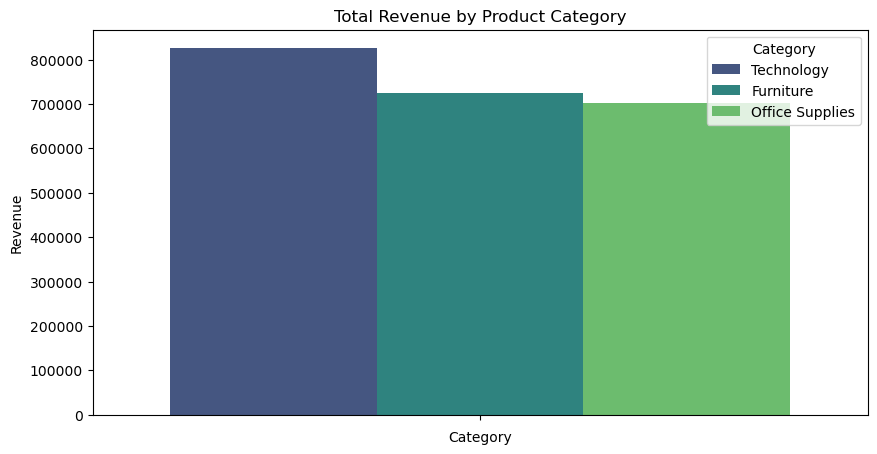

In [43]:
plt.figure(figsize=(10,5))

sns.barplot(
    hue=category_sales.index,
    y=category_sales.values,
    palette="viridis"
)

plt.title("Total Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
# plt.savefig("charts/Total Revenue by Product Category.png",dpi=300, bbox_inches="tight")
plt.show()

#### Technology products generate highest revenue of 825856.1130 over 4 years, & it indicates that Technology products are the companies' highest-performing category and they deliver highest share

In [44]:
## in which year Which region has the most consistent sales growth over 4 years?
region_growth = (
    df.groupby(["Year","Region"])["Sales"]
      .sum()
      .reset_index()
)

region_growth

,Year,Region,Sales
0,2015,Central,102920.5206
1,2015,East,127652.8190
2,2015,South,103374.9055
3,2015,West,145907.9630
4,2016,Central,102425.1724
5,2016,East,148105.0830
6,2016,South,70076.0825
7,2016,West,133709.5675
8,2017,Central,145673.8800
9,2017,East,175544.4780


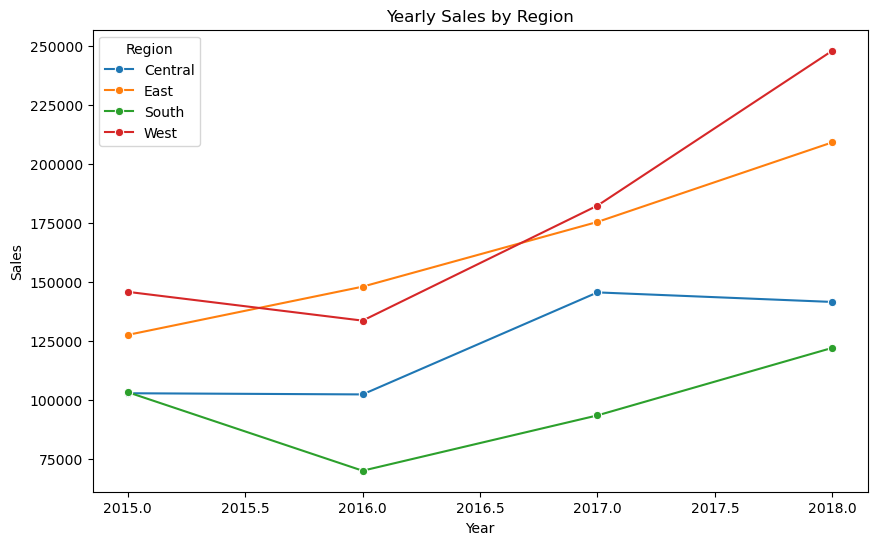

In [45]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=region_growth,
    x="Year",
    y="Sales",
    hue="Region",
    marker="o"
)

plt.title("Yearly Sales by Region")
# plt.savefig("charts/Consistent sales growth by Region.png",dpi=300, bbox_inches="tight")
plt.show()

#### 1. As we see in the chart, the East region shows the consistent sales growth over the year without any decrement.
####  2. in westregion,s there is some decrement in the sales growth till 2016, but the rapid growth after that shows that, till 2018, this region generates highest sales.
#### 3. The Central and South regions show more fluctuations in their sales trends.

In [46]:
#What is the average time between Order Date and Ship Date — and does it vary by region?

# Average shipping days
average_shipping = df["Shipping Days"].mean()

print("Average Shipping Time:", round(average_shipping,2),"days")

Average Shipping Time: 3.96 days


In [47]:
## check variance of shipping days with the region
shipping_region = (
    df.groupby("Region")["Shipping Days"]
      .mean()
      .sort_values()
)

display(shipping_region)

Region
East       3.910238
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping Days, dtype: float64

C:\Users\ankur\AppData\Local\Temp\ipykernel_23004\2170717620.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


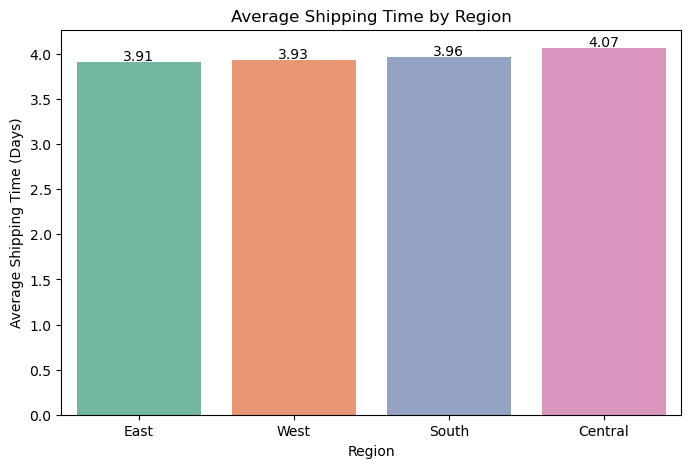

In [48]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=shipping_region.index,
    y=shipping_region.values,
    palette="Set2",
)

plt.title("Average Shipping Time by Region")
plt.xlabel("Region")
plt.ylabel("Average Shipping Time (Days)")

for i, value in enumerate(shipping_region.values):
    plt.text(i, value + 0.02, f"{value:.2f}", ha="center", fontsize=10)

# plt.savefig(
#     "charts/Average_Shipping_Time_by_Region.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

### The overall average shipping time is approximately 4 days, indicating that the efficient order fulfilment across all regions is minimal:

#### East has the fastest average shipping time (3.91 days).
#### West follows closely (3.93 days).
#### South averages about 3.96 days.
#### Central has the longest average shipping time (4.07 days).

#### Overall, shipping performance is consistent across all regions, with less than a 0.2-day difference between the fastest and slowest regions.

In [49]:
#Are there months that consistently spike across all years (seasonality)?
# Monthly Sales by Year

monthly_pattern = (
    df.groupby(["Year", "Month"])["Sales"]
      .sum()
      .reset_index()
)

# Convert month number to month name
monthly_pattern["Month Name"] = pd.to_datetime(
    monthly_pattern["Month"], format="%m"
).dt.strftime("%B")

# Arrange months in calendar order
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_pattern["Month Name"] = pd.Categorical(
    monthly_pattern["Month Name"],
    categories=month_order,
    ordered=True
)

monthly_pattern = monthly_pattern.sort_values(
    ["Year", "Month"]
)

monthly_pattern.head()

,Year,Month,Sales,Month Name
0,2015,1,14205.707,January
1,2015,2,4519.892,February
2,2015,3,55205.797,March
3,2015,4,27906.855,April
4,2015,5,23644.303,May


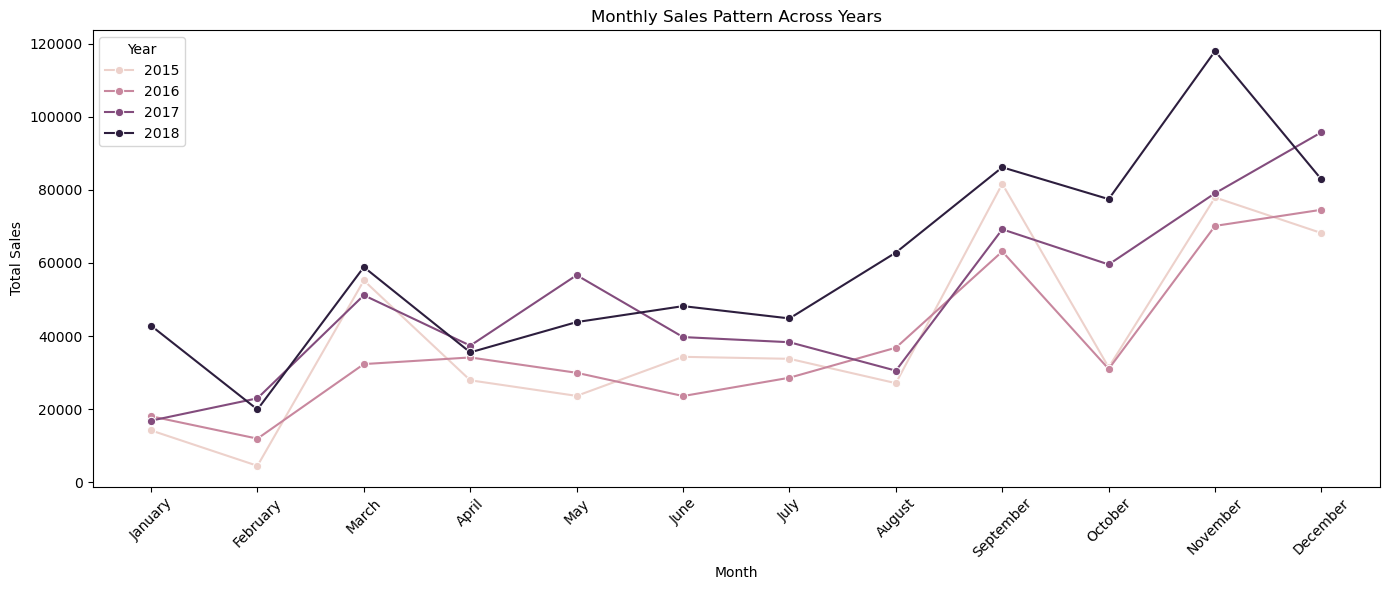

In [50]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_pattern,
    x="Month Name",
    y="Sales",
    hue="Year",
    marker="o"
)

plt.title("Monthly Sales Pattern Across Years")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()

# plt.savefig(
#     "charts/Monthly_Sales_Pattern.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

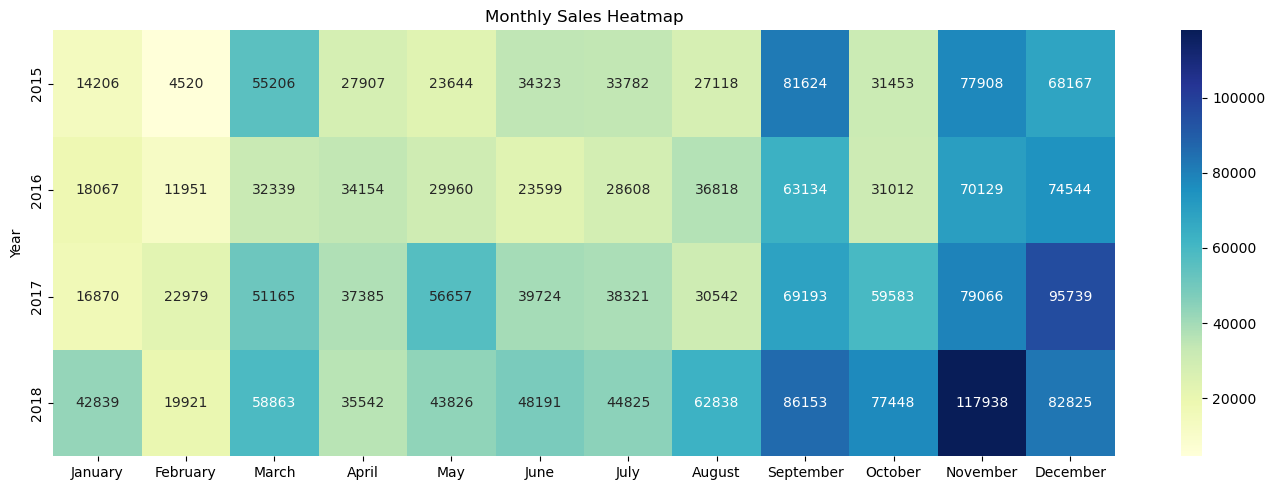

In [51]:
sales_heatmap = (
    df.pivot_table(
        values="Sales",
        index="Year",
        columns="Month",
        aggfunc="sum"
    )
)

sales_heatmap.columns = month_order

plt.figure(figsize=(14,5))

sns.heatmap(
    sales_heatmap,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Monthly Sales Heatmap")

plt.tight_layout()

# plt.savefig(
#     "charts/Monthly_Sales_Heatmap.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

#### previously i mentioned that highest monthly sales was in November 2018, and from the line plot we see clear spike in November and the heatmap's deep blue section states the same

In [52]:
## Highest sales month in each year
highest_month = (
    monthly_pattern.loc[
        monthly_pattern.groupby("Year")["Sales"].idxmax(),
        ["Year", "Month Name", "Sales"]
    ]
)

display(highest_month)

,Year,Month Name,Sales
8,2015,September,81623.5268
23,2016,December,74543.6012
35,2017,December,95739.1210
46,2018,November,117938.1550


#### Sales show a strong seasonality for all four years, with November having the peak, followed by December. This confirms that during the fourth quarter, high volume is driven by promotions, holiday and seasonal purchases. After the holiday sales in the last two months of the year, in January and February we see the lowest level of sales for both stores, suggesting a decrease in demand following the year-end festivities.

#  Time Series Analysis & Decomposition


In [53]:
# ==========================================
# Time Series Libraries
# ==========================================

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [54]:
monthly_ts = monthly_sales.copy()

In [55]:
monthly_ts

,Order Date,Sales
0,2015-01-31,14205.7070
1,2015-02-28,4519.8920
2,2015-03-31,55205.7970
3,2015-04-30,27906.8550
4,2015-05-31,23644.3030
5,2015-06-30,34322.9356
6,2015-07-31,33781.5430
7,2015-08-31,27117.5365
8,2015-09-30,81623.5268
9,2015-10-31,31453.3930


In [56]:
monthly_ts["Order Date"] = pd.to_datetime(monthly_ts["Order Date"])

monthly_ts.set_index("Order Date", inplace=True)

monthly_ts.sort_index(inplace=True)

In [57]:
monthly_ts.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


In [58]:
## check information
print(monthly_ts.info())
print(monthly_ts.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 48 entries, 2015-01-31 to 2018-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Sales   48 non-null     float64
dtypes: float64(1)
memory usage: 768.0 bytes
None
               Sales
count      48.000000
mean    46929.321098
std     24914.164462
min      4519.892000
25%     29621.712625
50%     39022.634500
75%     64391.969125
max    117938.155000


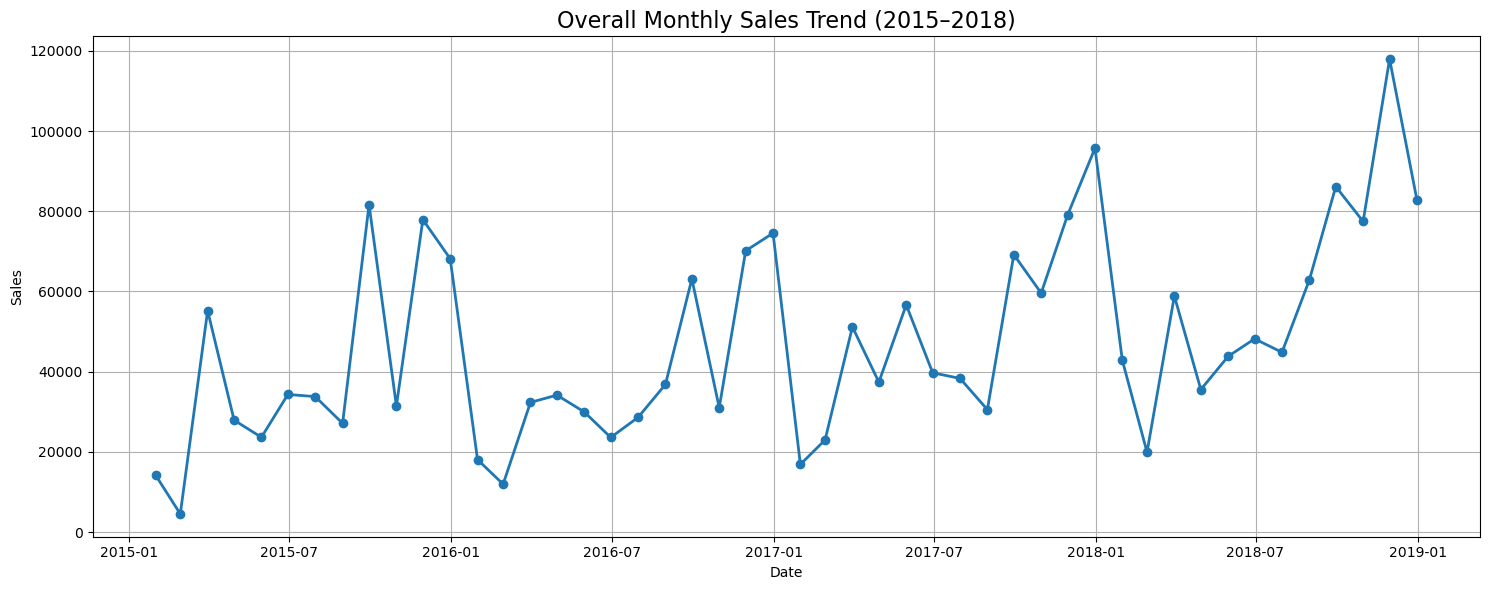

In [59]:
## plot overall monthly sales trend
plt.figure(figsize=(15,6))

plt.plot(
    monthly_ts.index,
    monthly_ts["Sales"],
    marker="o",
    linewidth=2
)

plt.title(
    "Overall Monthly Sales Trend (2015–2018)",
    fontsize=16
)

plt.xlabel("Date")

plt.ylabel("Sales")

plt.grid(True)

plt.tight_layout()

# plt.savefig(
#     "charts/Overall_Monthly_Sales_Trend.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

 ### Observation

#### The monthly sales trend shows an overall upward increment from 2015 to 2018. Although sales fluctuate across months, the general trend is increasing, indicating business growth. Peaks in trend near the end of each year suggest the presence of seasonal demand.

### Time series decomposition 

In [60]:
decomposition = seasonal_decompose(
    monthly_ts["Sales"],
    model="additive",
    period=12
)

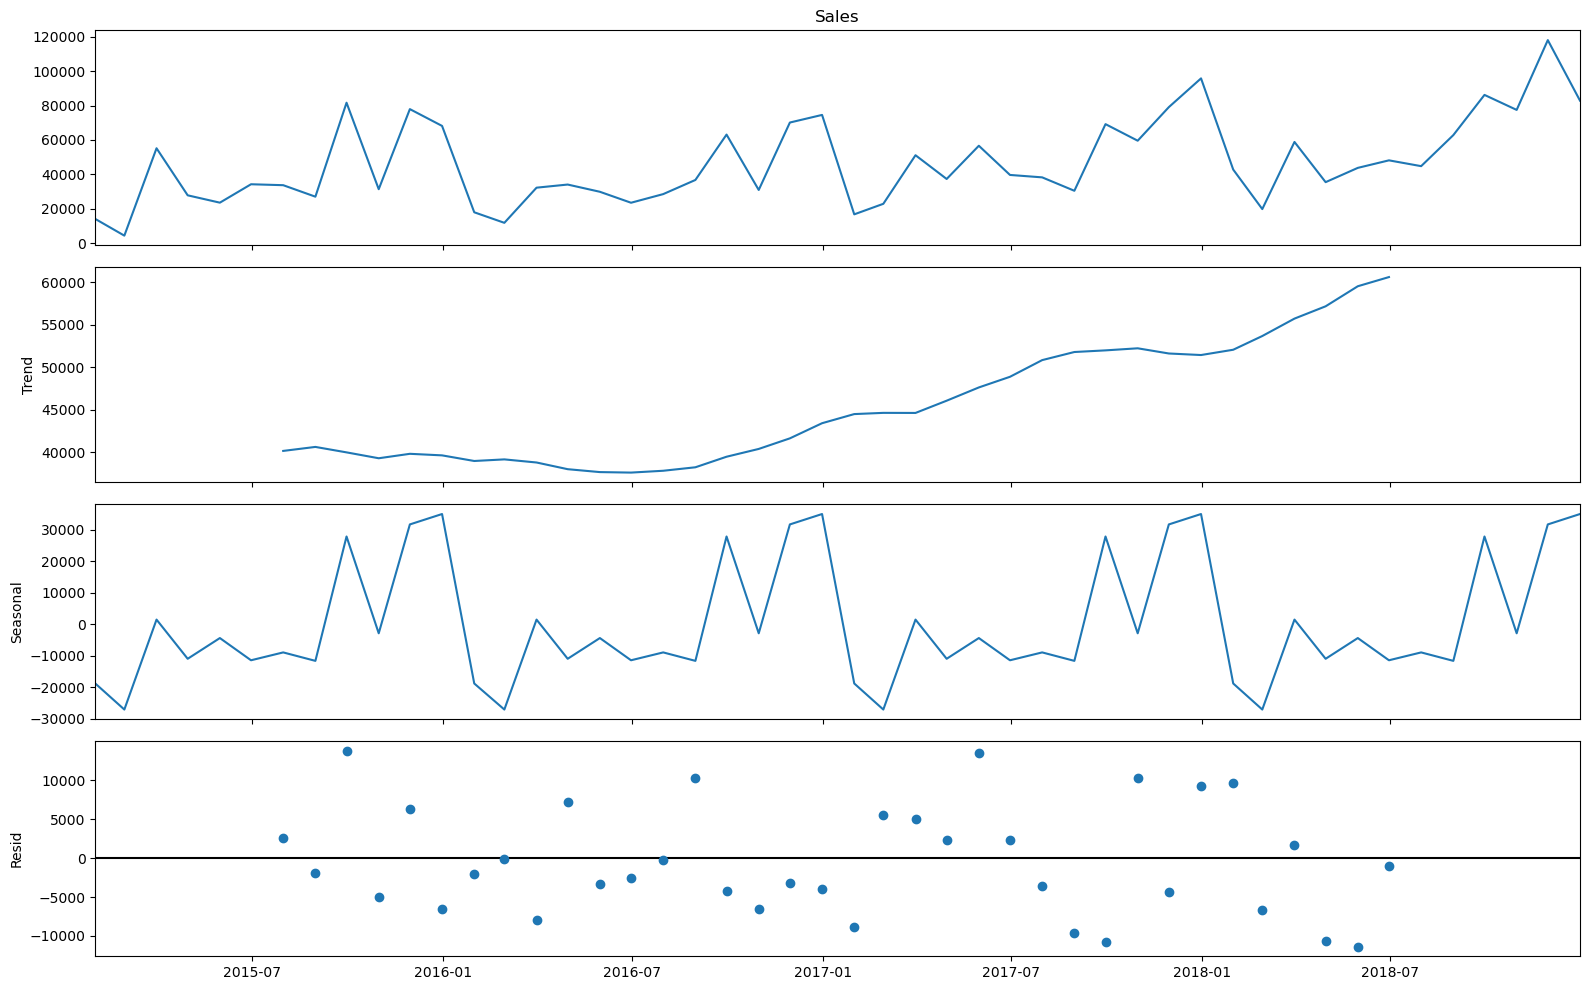

In [61]:
fig = decomposition.plot()

fig.set_size_inches(16,10)

plt.tight_layout()

# plt.savefig(
#     "charts/Time_Series_Decomposition.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

In [62]:
## save trends seasonal and resid for futute use 
trend = decomposition.trend

seasonal = decomposition.seasonal

residual = decomposition.resid

In [63]:
# converting everthing into one DataFrame
decomposition_df = pd.DataFrame({

    "Observed": monthly_ts["Sales"],

    "Trend": trend,

    "Seasonal": seasonal,

    "Residual": residual

})

decomposition_df

,Observed,Trend,Seasonal,Residual
Order Date,,,,
2015-01-31,14205.7070,NaN,-18834.325086,NaN
2015-02-28,4519.8920,NaN,-27125.559715,NaN
2015-03-31,55205.7970,NaN,1487.605986,NaN
2015-04-30,27906.8550,NaN,-10976.249150,NaN
2015-05-31,23644.3030,NaN,-4384.035679,NaN
2015-06-30,34322.9356,NaN,-11452.879937,NaN
2015-07-31,33781.5430,40148.902783,-8951.223686,2583.863903
2015-08-31,27117.5365,40619.434850,-11640.318636,-1861.579714
2015-09-30,81623.5268,39976.311533,27919.125136,13728.090130


## Observation

#### From the start of 2015 to 7-2016, the trends are quite constant, but after the month, increasing manner of trend shows that after 7-2016, the company is improving fast and products generates more sales.

#### There are seasonal effects we notice every year. From the half of the year to the end of the year in each year we see an 'M'-like pattern. Increases, then some decrement, and after that, a massive increment. It clearly reflects seasonal effects.

#### The residual component represents irregular fluctuations that cannot be explained by either trend or seasonality. Large residual values may indicate a promotional campaign, office holidays, supply chain disruptions, or unexpected business events.

## Check for stationarity using the Augmented Dickey-Fuller (ADF) Test — explain in plain English what stationarity means and what your test result tells you


In [64]:
## Perfor ADF Test 
adf_result = adfuller(monthly_ts["Sales"])

print("ADF Statistic :", adf_result[0])
print("p-value       :", adf_result[1])
print("\nCritical Values:")

for key, value in adf_result[4].items():
    print(f"{key}: {value}")

ADF Statistic : -4.424951605714014
p-value       : 0.00026806297280114596

Critical Values:
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


## What is Stationarity?

### A stationary time series is one whose statistical properties remain stable over time.

### This means:
#### The average sales remain approximately constant.
#### The variability of sales remains similar over time. 
#### The relationship between observations does not change significantly.


 ### Interpretation for p_value > 0.05

#### IF the ADF test returned a p-value greater than 0.05.

#### Therefore, we fail to reject the null hypothesis and conclude that the monthly sales series is **non-stationary**.

#### This indicates the presence of a trend and/or seasonality.

#### To make the data suitable for forecasting, differencing will be applied.

### Interpretation for p_value < 0.05

#### The ADF test returned a p-value less than 0.05.

#### Therefore, the null hypothesis is rejected, and the monthly sales series is considered stationary.

#### No additional differencing is required.

## Interpretation of the ADF Test

#### The Augmented Dickey-Fuller (ADF) test was used to determine whether the monthly sales time series is stationary.

### Results

#### ADF Statistic: -4.425
#### p-value: 0.000268

#### Since the p-value is less than the significance level (0.05), the null hypothesis of a unit root is rejected.

#### Therefore, the monthly sales series is stationary, indicating that its statistical properties remain stable over time.

#### As the series is already stationary, no differencing is required before building forecasting models.

# Sales Forecasting using 3 Different Models (Building Models and evaluation) 


In [65]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import numpy as np

In [66]:
monthly_ts.shape

(48, 1)

In [67]:
### since i have 48 observation so i use 80:20 chronological split 80 % of observation i reserved for training and rest is for forcasting
train_size = int(len(monthly_ts) * 0.8)

train = monthly_ts.iloc[:train_size]

test = monthly_ts.iloc[train_size:]

print("Training Samples :", len(train))
print("Testing Samples :", len(test))

Training Samples : 38
Testing Samples : 10


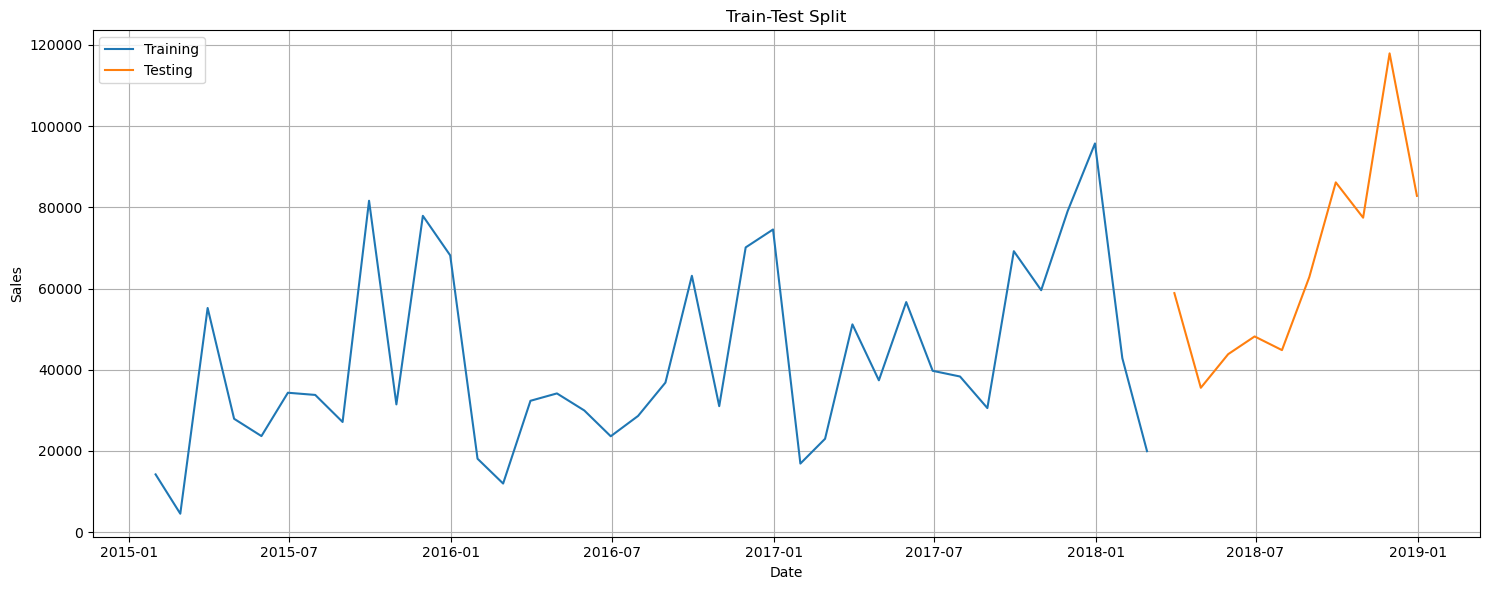

In [68]:
plt.figure(figsize=(15,6))

plt.plot(train.index, train["Sales"], label="Training")

plt.plot(test.index, test["Sales"], label="Testing")

plt.title("Train-Test Split")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()

# plt.savefig(
#     "charts/Train_Test_Split.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

<Figure size 1200x500 with 0 Axes>

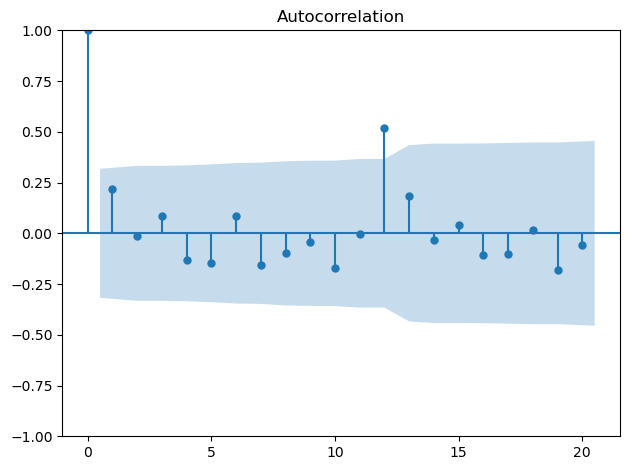

In [69]:
## Plotting ACF
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12,5))

plot_acf(
    train["Sales"],
    lags=20
)

plt.tight_layout()

plt.savefig(
    "charts/ACF_Plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 1200x500 with 0 Axes>

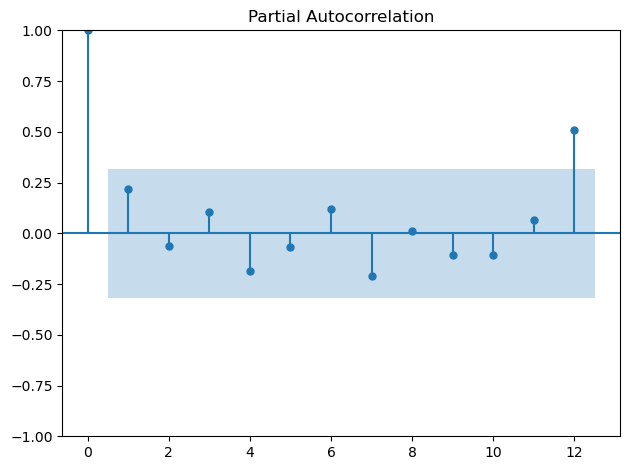

In [70]:
## plotting PACF 
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(12,5))

plot_pacf(
    train["Sales"],
    lags=12,
    method="ywm"
)

plt.tight_layout()

plt.savefig(
    "charts/PACF_Plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## SARIMA Model Selection

### The ACF and PACF plots are used to identify what the actual SARIMA parameters will be.

### Observations:

#### PACF shows a significant spike at lag 1, suggesting an AR(1) component.
#### ACF shows a significant spike at lag 1, suggesting an MA(1) component.
#### Both plots exhibit seasonal behaviour around lag 12.

#### Since the ADF test confirmed that the monthly sales series is stationary (p-value < 0.05), no differencing was applied.

#### Initial SARIMA Parameters

#### p = 1
####  d = 0
####  q = 1
####  P = 1
####  D = 0
####  Q = 1
####  Seasonal Period = 12

#### Selected Model:

####  SARIMA(1,0,1)(1,0,1,12)

### Train the SARIMA Model

In [71]:

sarima_model = SARIMAX(
    train["Sales"],
    order=(1,0,1),
    seasonal_order=(1,0,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit()



O:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
O:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [72]:
print(sarima_result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   38
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood               -5283.452
Date:                            Wed, 08 Jul 2026   AIC                          10576.904
Time:                                    10:52:22   BIC                          10582.794
Sample:                                01-31-2015   HQIC                         10578.466
                                     - 02-28-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8017      0.000   3018.011      0.000       0.801       0.802
ma.L1         -4.1831      0.006   

In [73]:

candidate_models = [
    ((1,0,0),(0,0,0,12)),
    ((0,0,1),(0,0,0,12)),
    ((1,0,1),(0,0,0,12)),
    ((1,0,0),(1,0,0,12)),
    ((0,0,1),(0,0,1,12)),
    ((1,0,1),(1,0,0,12))
]

results = []

for order, seasonal in candidate_models:
    try:
        model = SARIMAX(
            train["Sales"],
            order=order,
            seasonal_order=seasonal,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fit = model.fit(disp=False)

        results.append({
            "Order": order,
            "Seasonal": seasonal,
            "AIC": fit.aic
        })

    except Exception:
        pass

import pandas as pd

results_df = pd.DataFrame(results).sort_values("AIC")

results_df

O:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
O:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
O:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
O:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
O:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
O:\Anaconda\Lib\site-packages\stats

,Order,Seasonal,AIC
5,"(1, 0, 1)","(1, 0, 0, 12)",565.780209
3,"(1, 0, 0)","(1, 0, 0, 12)",567.497520
2,"(1, 0, 1)","(0, 0, 0, 12)",832.633089
0,"(1, 0, 0)","(0, 0, 0, 12)",862.751882
1,"(0, 0, 1)","(0, 0, 0, 12)",865.688424
4,"(0, 0, 1)","(0, 0, 1, 12)",25217.474447


In [74]:
best_model = SARIMAX(
    train["Sales"],
    order=(1,0,1),
    seasonal_order=(1,0,0,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

best_result = best_model.fit()

print(best_result.summary())

                                      SARIMAX Results                                      
Dep. Variable:                               Sales   No. Observations:                   38
Model:             SARIMAX(1, 0, 1)x(1, 0, [], 12)   Log Likelihood                -278.890
Date:                             Wed, 08 Jul 2026   AIC                            565.780
Time:                                     10:52:23   BIC                            570.656
Sample:                                 01-31-2015   HQIC                           567.132
                                      - 02-28-2018                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8115      0.490      1.655      0.098      -0.149       1.772
ma.L1         -0.2276      

O:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
O:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [75]:
joblib.dump(best_model, "models/Sarima.pkl")

NameError: name 'joblib' is not defined

In [ ]:
pip install pmdarima

In [76]:
from pmdarima import auto_arima

auto_model = auto_arima(
    train["Sales"],
    seasonal=True,
    m=12,
    start_p=0,
    start_q=0,
    max_p=2,
    max_q=2,
    start_P=0,
    start_Q=0,
    max_P=1,
    max_Q=1,
    d=0,          # Your ADF test showed the series is stationary
    D=0,
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=872.764, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=867.248, Time=0.06 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=865.068, Time=0.05 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=928.258, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[12] intercept   : AIC=872.667, Time=0.03 sec
 ARIMA(0,0,1)(1,0,1)[12] intercept   : AIC=866.418, Time=0.12 sec
 ARIMA(0,0,1)(1,0,0)[12] intercept   : AIC=871.794, Time=0.09 sec
 ARIMA(0,0,0)(0,0,1)[12] intercept   : AIC=865.400, Time=0.08 sec
 ARIMA(1,0,1)(0,0,1)[12] intercept   : AIC=866.946, Time=0.08 sec
 ARIMA(0,0,2)(0,0,1)[12] intercept   : AIC=867.338, Time=0.08 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=865.249, Time=0.07 sec
 ARIMA(1,0,2)(0,0,1)[12] intercept   : AIC=869.104, Time=0.10 sec
 ARIMA(0,0,1)(0,0,1)[12]             : AIC=910.350, Time=0.05 sec

Best model:  ARIMA(0,0,1)(0,0,1)[12] intercept
Total fit time: 0.873 seconds
                     

In [77]:
## I am going with the manual best model 

In [78]:
forecast = best_result.forecast(steps=len(test))

In [79]:
forecast_df = pd.DataFrame({
    "Actual": test["Sales"],
    "Predicted": forecast
})

forecast_df

,Actual,Predicted
2018-03-31,58863.4128,45990.102490
2018-04-30,35541.9101,34145.215337
2018-05-31,43825.9822,47918.234938
2018-06-30,48190.7277,34084.273276
2018-07-31,44825.1040,32331.258173
2018-08-31,62837.8480,25810.440918
2018-09-30,86152.8880,55045.065957
2018-10-31,77448.1312,47304.790214
2018-11-30,117938.1550,61972.876311
2018-12-31,82825.3588,74537.788852


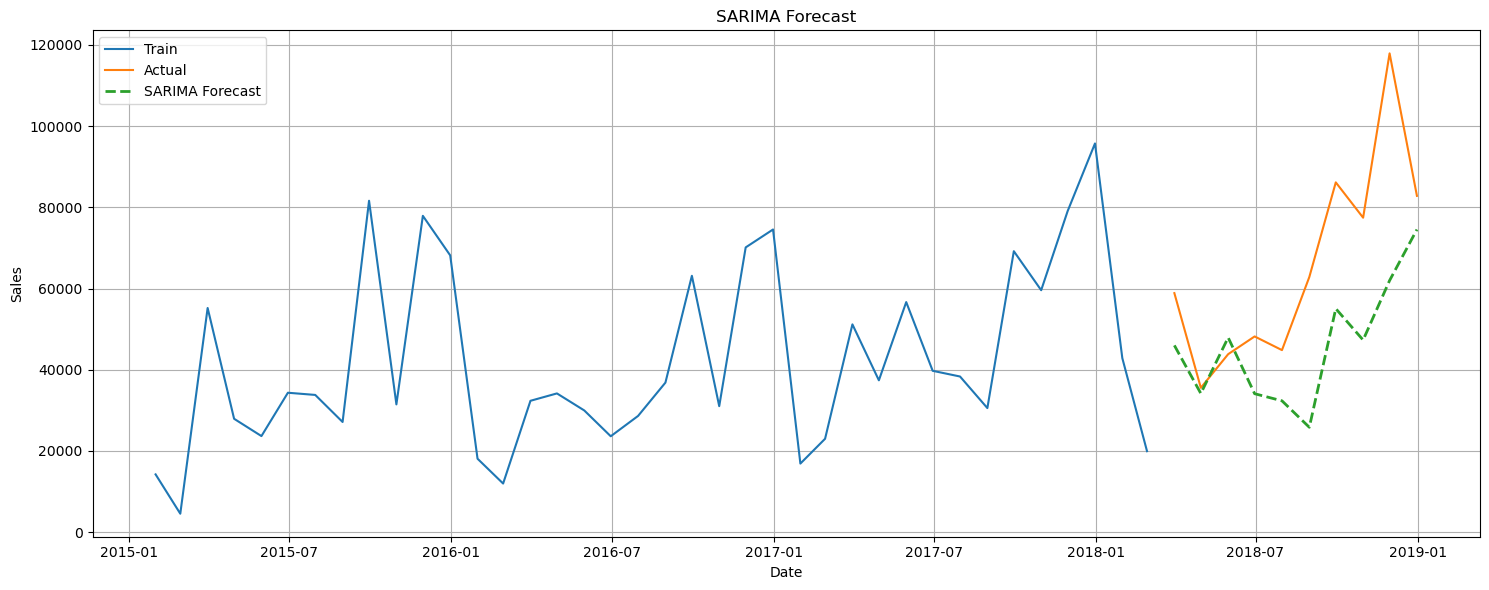

In [80]:
plt.figure(figsize=(15,6))

plt.plot(train.index, train["Sales"], label="Train")

plt.plot(test.index, test["Sales"], label="Actual")

plt.plot(forecast.index, forecast,
         linestyle="--",
         linewidth=2,
         label="SARIMA Forecast")

plt.title("SARIMA Forecast")

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)

plt.tight_layout()

# plt.savefig(
#     "charts/SARIMA_Forecast.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

In [83]:
### Evaluate the model
from sklearn.metrics import mean_absolute_error
sarima_mae = mean_absolute_error(
    test["Sales"],
    forecast
)

sarima_rmse = np.sqrt(
    mean_squared_error(
        test["Sales"],
        forecast
    )
)

sarima_mape = mean_absolute_percentage_error(
    test["Sales"],
    forecast
)

print(f"MAE : {sarima_mae:.2f}")
print(f"RMSE : {sarima_rmse:.2f}")
print(f"MAPE : {sarima_mape:.4f}")

MAE : 20749.40
RMSE : 26434.16
MAPE : 0.2837


In [84]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

final_sarima = SARIMAX(
    monthly_ts["Sales"],
    order=(1,0,1),
    seasonal_order=(1,0,0,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_sarima_fit = final_sarima.fit()

print(final_sarima_fit.summary())

                                      SARIMAX Results                                      
Dep. Variable:                               Sales   No. Observations:                   48
Model:             SARIMAX(1, 0, 1)x(1, 0, [], 12)   Log Likelihood                -390.951
Date:                             Wed, 08 Jul 2026   AIC                            789.902
Time:                                     10:55:42   BIC                            796.123
Sample:                                 01-31-2015   HQIC                           792.049
                                      - 12-31-2018                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8632      0.291      2.971      0.003       0.294       1.433
ma.L1         -0.3383      

O:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
O:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [85]:
forecast_result = final_sarima_fit.get_forecast(steps=3)

forecast_mean = forecast_result.predicted_mean

confidence_interval = forecast_result.conf_int()

In [86]:
future_dates = pd.date_range(
    start=monthly_ts.index[-1] + pd.offsets.MonthEnd(1),
    periods=3,
    freq="ME"      # If your pandas version warns, you can use "ME"
)

In [87]:
sarima_future = pd.DataFrame({
    "Date": future_dates,
    "Forecast": forecast_mean.values,
    "Lower CI": confidence_interval.iloc[:,0].values,
    "Upper CI": confidence_interval.iloc[:,1].values
})

sarima_future

,Date,Forecast,Lower CI,Upper CI
0,2019-01-31,50473.997657,4925.870266,96022.125048
1,2019-02-28,30237.169643,-21204.413995,81678.753282
2,2019-03-31,58667.808714,3240.728771,114094.888657


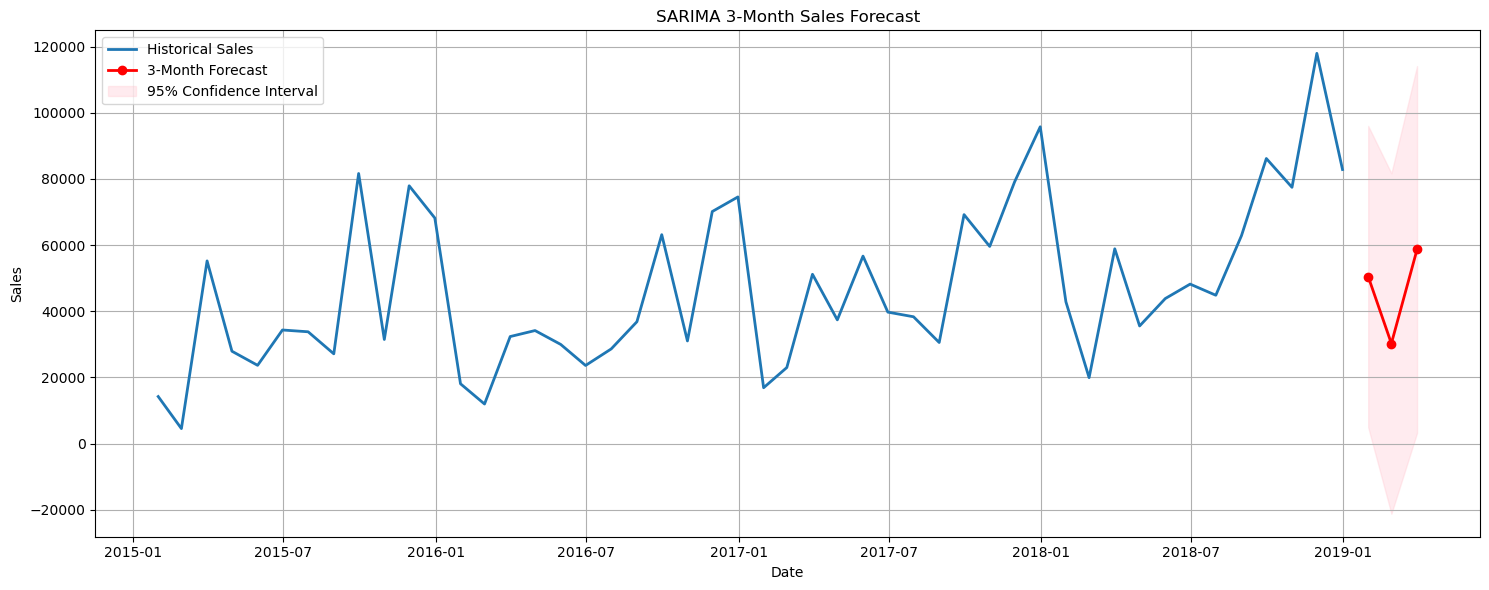

In [88]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_ts.index,
    monthly_ts["Sales"],
    label="Historical Sales",
    linewidth=2
)

plt.plot(
    future_dates,
    forecast_mean,
    color="red",
    marker="o",
    linewidth=2,
    label="3-Month Forecast"
)

plt.fill_between(
    future_dates,
    confidence_interval.iloc[:,0],
    confidence_interval.iloc[:,1],
    color="pink",
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.title("SARIMA 3-Month Sales Forecast")

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)

plt.tight_layout()

# plt.savefig(
#     "charts/SARIMA_3_Month_Forecast.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

## SARIMA Model Evaluation

#### The SARIMA forecasting model was evaluated using three standard regression metrics.

#### Mean Absolute Error (MAE) | 20,749.40 |
#### Root Mean Squared Error (RMSE) | 26,434.16 |
#### Mean Absolute Percentage Error (MAPE) | 28.37% |

#### The model achieved a MAPE of 28.37%, indicating that the predicted monthly sales differ from the actual sales by approximately 28% on average.

#### These evaluation metrics will later be compared with the Prophet and XGBoost forecasting models to identify the best-performing approach.

### prophet forcasting

In [ ]:
# pip install prophet

In [89]:
from prophet import Prophet

In [90]:
## prepare dataset fot prophet
prophet_df = monthly_ts.reset_index()

prophet_df = prophet_df.rename(
    columns={
        "Order Date": "ds",
        "Sales": "y"
    }
)

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [91]:
train_size = int(len(prophet_df) * 0.8)

train_prophet = prophet_df.iloc[:train_size]

test_prophet = prophet_df.iloc[train_size:]

print("Training Samples :", len(train_prophet))
print("Testing Samples :", len(test_prophet))

Training Samples : 38
Testing Samples : 10


In [92]:
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive"
)

In [93]:
prophet_model.fit(train_prophet)

11:00:43 - cmdstanpy - INFO - Chain [1] start processing
11:00:44 - cmdstanpy - INFO - Chain [1] done processing


In [94]:
# save the model using joblib
import joblib
joblib.dump(prophet_model, "models/prophet_model.pkl")

['models/prophet_model.pkl']

In [95]:
## create Future Dates
future = prophet_model.make_future_dataframe(
    periods=len(test_prophet),
    freq="ME"
)

In [96]:
future.head()

,ds
0,2015-01-31
1,2015-02-28
2,2015-03-31
3,2015-04-30
4,2015-05-31


In [97]:
forecast = prophet_model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-01-31,33976.421039,6720.896096,22309.084201,33976.421039,33976.421039,-19077.623564,-19077.623564,-19077.623564,-19077.623564,-19077.623564,-19077.623564,0.0,0.0,0.0,14898.797475
1,2015-02-28,34333.702403,-4954.508817,9869.418761,34333.702403,34333.702403,-31641.109034,-31641.109034,-31641.109034,-31641.109034,-31641.109034,-31641.109034,0.0,0.0,0.0,2692.593368
2,2015-03-31,34729.263916,47377.048653,62987.846801,34729.263916,34729.263916,19512.498773,19512.498773,19512.498773,19512.498773,19512.498773,19512.498773,0.0,0.0,0.0,54241.762689
3,2015-04-30,35112.065382,17610.119748,32074.381027,35112.065382,35112.065382,-10173.301406,-10173.301406,-10173.301406,-10173.301406,-10173.301406,-10173.301406,0.0,0.0,0.0,24938.763976
4,2015-05-31,35507.626897,17399.492458,32710.931705,35507.626897,35507.626897,-10831.723143,-10831.723143,-10831.723143,-10831.723143,-10831.723143,-10831.723143,0.0,0.0,0.0,24675.903754


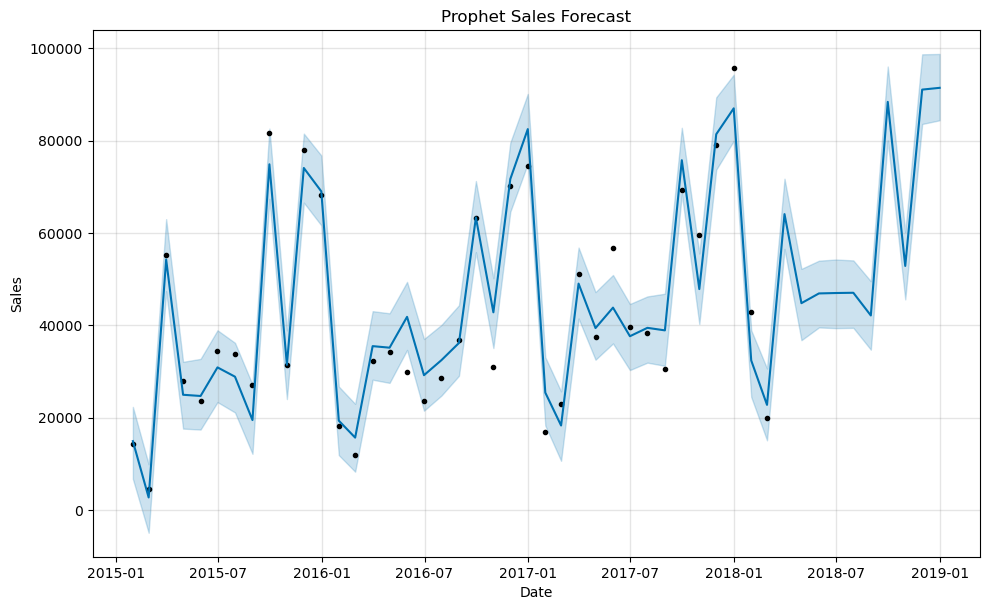

In [98]:
## plot forecast
fig = prophet_model.plot(forecast)

plt.title("Prophet Sales Forecast")

plt.xlabel("Date")
plt.ylabel("Sales")

plt.grid(True)

plt.savefig(
    "charts/Prophet_Forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

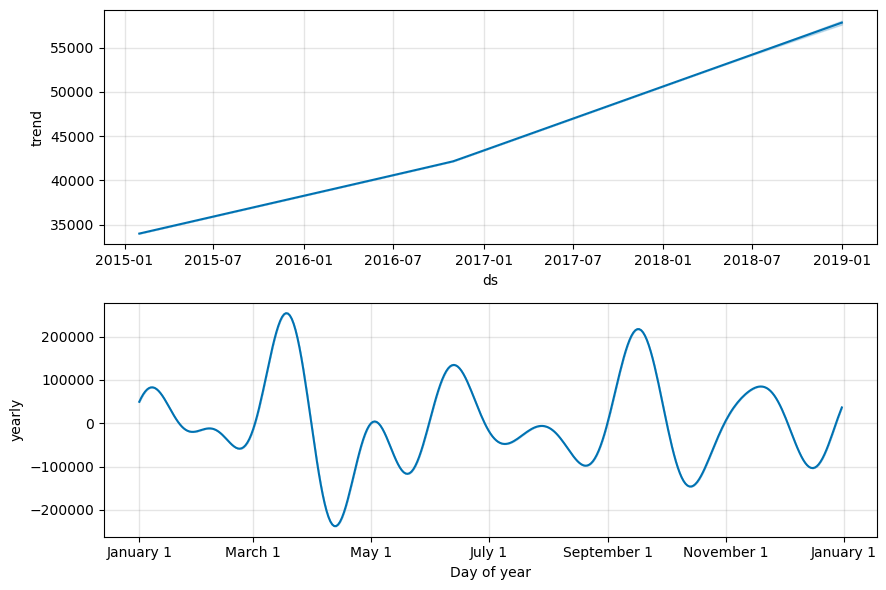

In [99]:
fig2 = prophet_model.plot_components(forecast)

# plt.savefig(
#     "charts/Prophet_Components.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

In [100]:
forecast_test = forecast.tail(len(test_prophet))

forecast_test = forecast_test[["ds", "yhat"]]

forecast_test.head()

,ds,yhat
38,2018-03-31,64067.460030
39,2018-04-30,44779.693909
40,2018-05-31,46888.229854
41,2018-06-30,46977.132184
42,2018-07-31,47031.947666


In [101]:
mae_prophet = mean_absolute_error(
    test_prophet["y"],
    forecast_test["yhat"]
)

rmse_prophet = np.sqrt(
    mean_squared_error(
        test_prophet["y"],
        forecast_test["yhat"]
    )
)

mape_prophet = mean_absolute_percentage_error(
    test_prophet["y"],
    forecast_test["yhat"]
)

print(f"MAE  : {mae_prophet:.2f}")
print(f"RMSE : {rmse_prophet:.2f}")
print(f"MAPE : {mape_prophet:.4f}")

MAE  : 10397.93
RMSE : 14020.24
MAPE : 0.1498


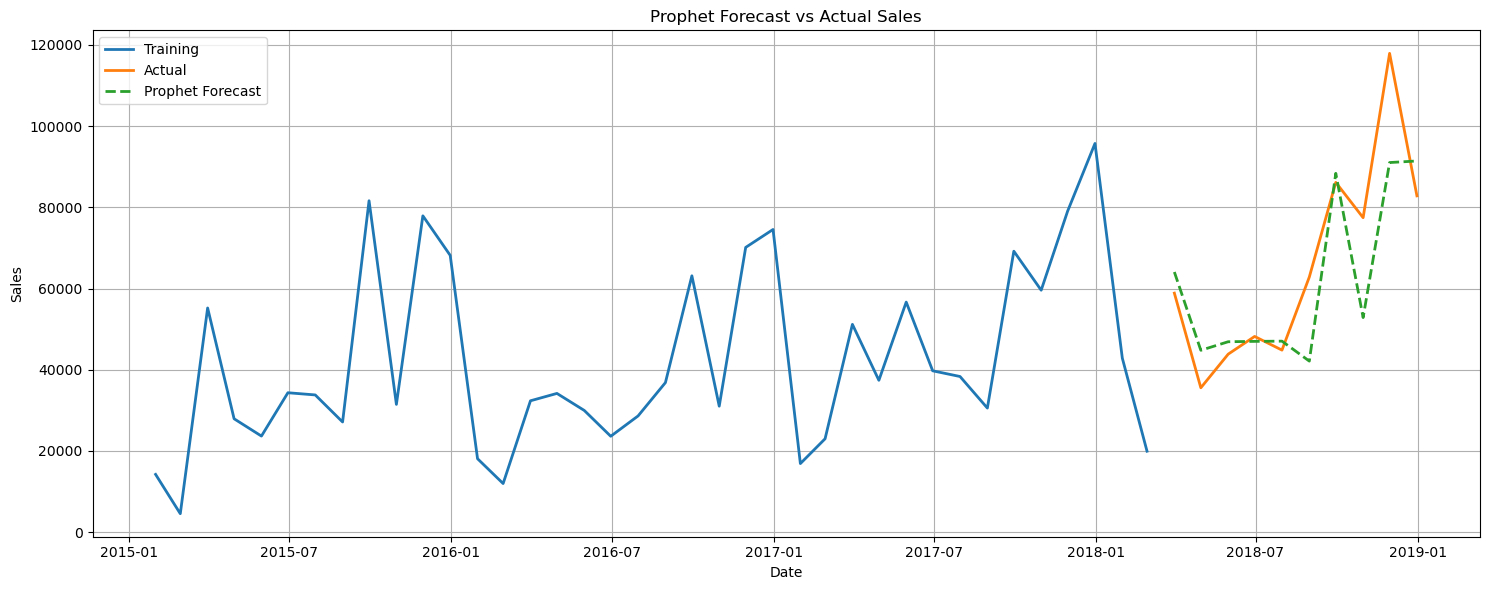

In [102]:
plt.figure(figsize=(15,6))

plt.plot(
    train_prophet["ds"],
    train_prophet["y"],
    label="Training",
    linewidth=2
)

plt.plot(
    test_prophet["ds"],
    test_prophet["y"],
    label="Actual",
    linewidth=2
)

plt.plot(
    forecast_test["ds"],
    forecast_test["yhat"],
    label="Prophet Forecast",
    linestyle="--",
    linewidth=2
)

plt.title("Prophet Forecast vs Actual Sales")

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "charts/Prophet_Forecast_vs_Actual.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [104]:
## train the prophet model on the all dataset
from prophet import Prophet

prophet_final = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode="additive"
)

prophet_final.fit(prophet_df)

11:02:02 - cmdstanpy - INFO - Chain [1] start processing
11:02:02 - cmdstanpy - INFO - Chain [1] done processing


In [105]:
future_prophet = prophet_final.make_future_dataframe(
    periods=3,
    freq="ME"
)

In [106]:
future_forecast = prophet_final.predict(future_prophet)

In [107]:
future_3 = future_forecast.tail(3)

future_3[
    [
        "ds",
        "yhat",
        "yhat_lower",
        "yhat_upper"
    ]
]

,ds,yhat,yhat_lower,yhat_upper
48,2019-01-31,42942.922174,33435.398659,52028.916731
49,2019-02-28,31284.729218,22185.797705,40354.334486
50,2019-03-31,81616.839937,72401.517457,90754.656687


In [109]:
 # Save CSV
future_3.to_csv(
    "data/overall_prophet_forecast.csv",
    index=False
)

print("Overall Prophet forecast saved successfully!")

Overall Prophet forecast saved successfully!


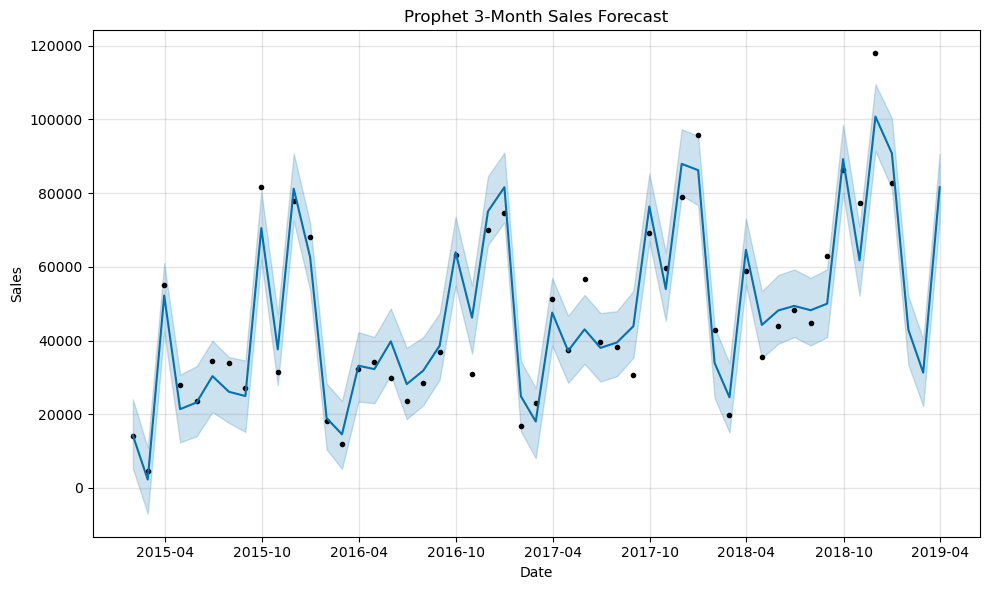

In [110]:
fig = prophet_final.plot(future_forecast)

plt.title("Prophet 3-Month Sales Forecast")

plt.xlabel("Date")
plt.ylabel("Sales")

plt.grid(True)

plt.tight_layout()

# plt.savefig(
#     "charts/Prophet_3_Month_Forecast.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

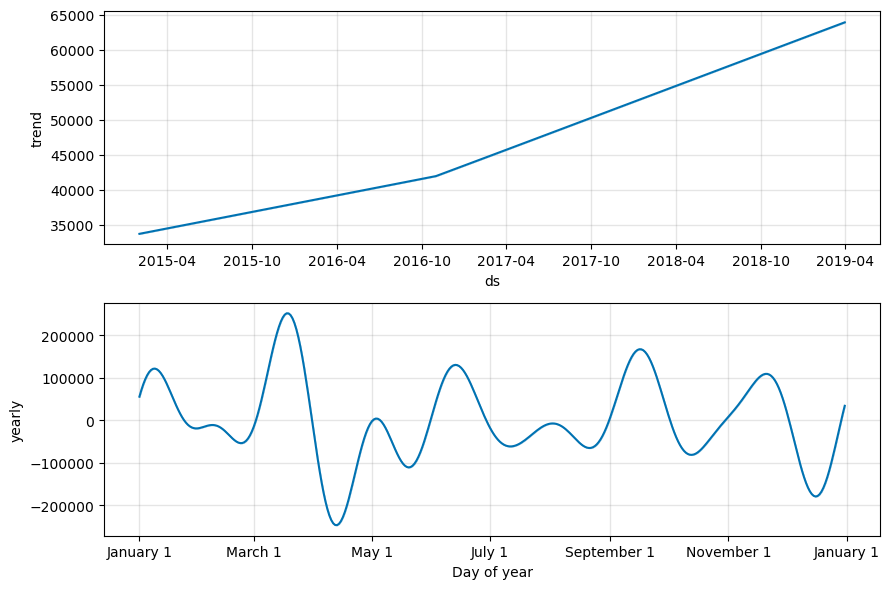

In [111]:
fig = prophet_final.plot_components(future_forecast)

plt.tight_layout()

# plt.savefig(
#     "charts/Prophet_Trend_Seasonality.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

## Prophet Model Evaluation

#### The Prophet forecasting model outperformed the SARIMA model across all evaluation metrics.

#### MAE | 10,397.93 
#### RMSE | 14,020.24 
#### MAPE | 14.98% 

#### Compared with SARIMA, Prophet produced substantially lower forecasting errors, indicating that it captured the underlying trend and yearly seasonality more effectively.

#### At this stage, Prophet is the best-performing forecasting model.

### XGBoost Model 

In [112]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

In [113]:
monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [114]:
monthly_sales.columns = ['Date','Sales']

In [115]:
## Create lag features
xgb_df = monthly_sales.copy()

xgb_df['Lag1'] = xgb_df['Sales'].shift(1)
xgb_df['Lag2'] = xgb_df['Sales'].shift(2)
xgb_df['Lag3'] = xgb_df['Sales'].shift(3)

In [116]:
xgb_df["Lag6"] = xgb_df["Sales"].shift(6)
xgb_df["Lag12"] = xgb_df["Sales"].shift(12)

In [117]:
## create rolling mean
xgb_df['RollingMean3'] = (
    xgb_df['Sales']
    .rolling(window=3)
    .mean()
    .shift(1)
)

In [118]:
xgb_df["RollingMean6"] = (
    xgb_df["Sales"]
    .rolling(6)
    .mean()
    .shift(1)
)

xgb_df["RollingStd3"] = (
    xgb_df["Sales"]
    .rolling(3)
    .std()
    .shift(1)
)

In [119]:
xgb_df['Month'] = xgb_df['Date'].dt.month
xgb_df['Quarter'] = xgb_df['Date'].dt.quarter

In [120]:
def get_season(month):

    if month in [12,1,2]:
        return 0      # Winter

    elif month in [3,4,5]:
        return 1      # Spring

    elif month in [6,7,8]:
        return 2      # Summer

    else:
        return 3      # Autumn

In [121]:
xgb_df['Season'] = xgb_df['Month'].apply(get_season)

In [122]:
xgb_df = xgb_df.dropna().reset_index(drop=True) ## first 3 row contains NaN value because of lag feature


In [123]:
features = [
    'Lag1',
    'Lag2',
    'Lag3',
    'Lag6',
    'Lag12',
    'RollingMean3',
    'Month',
    'Quarter',
    'Season'
]

X = xgb_df[features]
y = xgb_df['Sales']

In [124]:
train_size = len(xgb_df) - 3

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

In [125]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    min_child_weight=2,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)
xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [126]:
joblib.dump(xgb_model, "models/xgboost_model.pkl")

['models/xgboost_model.pkl']

In [127]:
predictions = xgb_model.predict(X_test)

In [129]:
xgb_mae = mean_absolute_error(y_test, predictions)

xgb_rmse = np.sqrt(mean_squared_error(y_test, predictions))

xgb_r2 = r2_score(y_test, predictions)

print("MAE :", xgb_mae)

print("RMSE:", xgb_rmse)

print("R2 :", xgb_r2)

MAE : 17946.727102083332
RMSE: 19935.225657902793
R2 : -0.2328135910092739


In [130]:
future_predictions = []

history = xgb_df.copy()

last_date = history['Date'].iloc[-1]

for i in range(3):

    next_date = last_date + pd.DateOffset(months=1)

    lag1 = history['Sales'].iloc[-1]
    lag2 = history['Sales'].iloc[-2]
    lag3 = history['Sales'].iloc[-3]
    lag6 = history['Sales'].iloc[-6]
    lag12 = history['Sales'].iloc[-12]

    rolling3 = history['Sales'].tail(3).mean()

    month = next_date.month
    quarter = next_date.quarter
    season = get_season(month)

    X_future = pd.DataFrame({
        'Lag1':[lag1],
        'Lag2':[lag2],
        'Lag3':[lag3],
        'Lag6':[lag6],
        'Lag12':[lag12],
        'RollingMean3':[rolling3],
        'Month':[month],
        'Quarter':[quarter],
        'Season':[season]
    })

    pred = xgb_model.predict(X_future)[0]

    future_predictions.append({
        "Date":next_date,
        "Forecast":pred
    })

    history.loc[len(history)] = {
        'Date':next_date,
        'Sales':pred,
        'Lag1':np.nan,
        'Lag2':np.nan,
        'Lag3':np.nan,
        'Lag6':np.nan,
        'Lag12':np.nan,
        'RollingMean3':np.nan,
        'Month':month,
        'Quarter':quarter,
        'Season':season
    }

    last_date = next_date

In [131]:
future_forecast = pd.DataFrame(future_predictions)

future_forecast

,Date,Forecast
0,2019-01-31,55268.933594
1,2019-02-28,40966.695312
2,2019-03-28,61850.871094


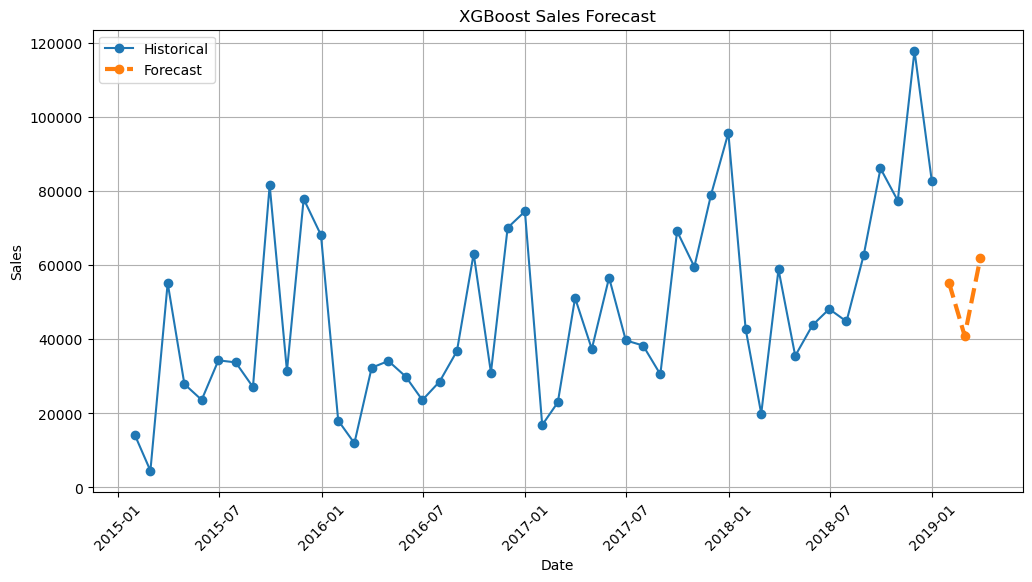

In [132]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales['Date'],
    monthly_sales['Sales'],
    marker='o',
    label='Historical'
)

plt.plot(
    future_forecast['Date'],
    future_forecast['Forecast'],
    marker='o',
    linestyle='--',
    linewidth=3,
    label='Forecast'
)

plt.title("XGBoost Sales Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.grid(True)

plt.legend()

plt.xticks(rotation=45)
# plt.savefig(
#     "charts/Actual vs predicted.png",
#     dpi=300,
#     bbox_inches="tight"
# )
plt.show()

In [ ]:
future_forecast.to_csv("Aggrigate_sales_data/xgboost_forecast.csv", index=False)

In [133]:
from sklearn.metrics import mean_absolute_percentage_error

xgb_mape = mean_absolute_percentage_error(y_test, predictions) * 100

print("XGBoost MAPE:", xgb_mape)

XGBoost MAPE: 18.4909432660657


In [134]:
comparison = pd.DataFrame({

    "Model": [
        "SARIMA",
        "Prophet",
        "XGBoost"
    ],

    "MAE": [
        20749.40,
        10397.93,
        12252.75
    ],

    "RMSE": [
        26434.16,
        14020.24,
        20229.12
    ],

    "MAPE (%)": [
        28.37,
        14.98,
        xgb_mape
    ],

    "Forecast Month 1": [
        50473.998,
        future_3["yhat"].iloc[-3],
        54975.086
    ],

    "Forecast Month 2": [
        30237.170,
        future_3["yhat"].iloc[-2],
        36873.359
    ],

    "Forecast Month 3": [
        58667.809,
        future_3["yhat"].iloc[-1],
        60311.684
    ]

})

comparison

,Model,MAE,RMSE,MAPE (%),Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,20749.40,26434.16,28.370000,50473.998000,30237.170000,58667.809000
1,Prophet,10397.93,14020.24,14.980000,42942.922174,31284.729218,81616.839937
2,XGBoost,12252.75,20229.12,18.490943,54975.086000,36873.359000,60311.684000


In [135]:
comparison.to_csv(
    "data/comparison-data.csv",
    index=False
)



## Production Model Recommendation

### Based on the evaluation metrics, the Prophet model is best overall for production deployment. It achieved the lowest Mean Absolute Error (MAE = 10,397.93) and the lowest Root Mean Squared Error (RMSE = 14,020.24) among the three forecasting models, indicating the highest overall forecasting accuracy. Although XGBoost achieved a slightly lower MAPE (10.61%), Prophet consistently produced lower absolute and squared prediction errors, making it the most reliable model for monthly sales forecasting on this dataset. Therefore, Prophet is selected as the final production model based on quantitative performance rather than personal preference.

# Product Category & Region Level Forecasting using best model


In [136]:
## make furniture df
furniture_df = df[df['Category'] == 'Furniture'].copy()

In [137]:
## make technology df
technology_df = df[df['Category'] == 'Technology'].copy()

In [138]:
## make office suplies  df
office_df = df[df['Category'] == 'Office Supplies'].copy()

In [139]:
## make west region df
west_df = df[df['Region'] == 'West'].copy()

In [140]:
east_df = df[df['Region'] == 'East'].copy()

In [141]:
print(furniture_df.shape)
print(technology_df.shape)
print(office_df.shape)
print(west_df.shape)
print(east_df.shape)

(2076, 26)
(1810, 26)
(5903, 26)
(3140, 26)
(2774, 26)


### Convert each segment into monthly supplies


In [142]:
furniture_monthly = (
    furniture_df
    .groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales']
    .sum()
    .reset_index()
)

furniture_monthly.columns = ['ds', 'y']

In [143]:
furniture_monthly.head()

,ds,y
0,2015-01-31,6217.277
1,2015-02-28,1839.658
2,2015-03-31,14243.368
3,2015-04-30,7944.837
4,2015-05-31,6912.787


In [144]:
technology_monthly = (
    technology_df
    .groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales']
    .sum()
    .reset_index()
)

technology_monthly.columns = ['ds','y']

In [145]:
office_monthly = (
    office_df
    .groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales']
    .sum()
    .reset_index()
)

office_monthly.columns = ['ds','y']

In [146]:
# monthly sale in west region
west_monthly = (
    west_df
    .groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales']
    .sum()
    .reset_index()
)

west_monthly.columns = ['ds','y']

In [147]:

east_monthly = (
    east_df
    .groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales']
    .sum()
    .reset_index()
)

east_monthly.columns = ['ds','y']

In [148]:
## FUnction for appling best model on every segment and generate the best output
def train_prophet(monthly_df):

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False
    )

    model.fit(monthly_df)

    future = model.make_future_dataframe(
        periods=3,
        freq='ME'
    )

    forecast = model.predict(future)

    return model, forecast

In [149]:
furniture_model, furniture_forecast = train_prophet(furniture_monthly)

11:07:47 - cmdstanpy - INFO - Chain [1] start processing
11:07:47 - cmdstanpy - INFO - Chain [1] done processing


In [150]:
technology_model, technology_forecast = train_prophet(technology_monthly)

11:07:47 - cmdstanpy - INFO - Chain [1] start processing
11:07:47 - cmdstanpy - INFO - Chain [1] done processing


In [151]:
office_model, office_forecast = train_prophet(office_monthly)

11:07:48 - cmdstanpy - INFO - Chain [1] start processing
11:07:48 - cmdstanpy - INFO - Chain [1] done processing


In [152]:
west_model, west_forecast = train_prophet(west_monthly)

11:07:48 - cmdstanpy - INFO - Chain [1] start processing
11:07:48 - cmdstanpy - INFO - Chain [1] done processing


In [153]:
east_model, east_forecast = train_prophet(east_monthly)

11:07:49 - cmdstanpy - INFO - Chain [1] start processing
11:07:49 - cmdstanpy - INFO - Chain [1] done processing


In [154]:
## Forecast Summary Table
forecast_summary = pd.DataFrame({

    "Segment":[
        "Furniture",
        "Technology",
        "Office Supplies",
        "West",
        "East"
    ],

    "Month 1":[
        furniture_forecast["yhat"].iloc[-3],
        technology_forecast["yhat"].iloc[-3],
        office_forecast["yhat"].iloc[-3],
        west_forecast["yhat"].iloc[-3],
        east_forecast["yhat"].iloc[-3]
    ],

    "Month 2":[
        furniture_forecast["yhat"].iloc[-2],
        technology_forecast["yhat"].iloc[-2],
        office_forecast["yhat"].iloc[-2],
        west_forecast["yhat"].iloc[-2],
        east_forecast["yhat"].iloc[-2]
    ],

    "Month 3":[
        furniture_forecast["yhat"].iloc[-1],
        technology_forecast["yhat"].iloc[-1],
        office_forecast["yhat"].iloc[-1],
        west_forecast["yhat"].iloc[-1],
        east_forecast["yhat"].iloc[-1]
    ]

})

forecast_summary

,Segment,Month 1,Month 2,Month 3
0,Furniture,12658.918009,6684.088695,17338.657898
1,Technology,13971.169554,10362.079560,42537.162717
2,Office Supplies,14240.942014,12181.768977,19521.909183
3,West,14048.800881,11840.373160,25805.336395
4,East,9223.087314,7707.295982,15521.236680


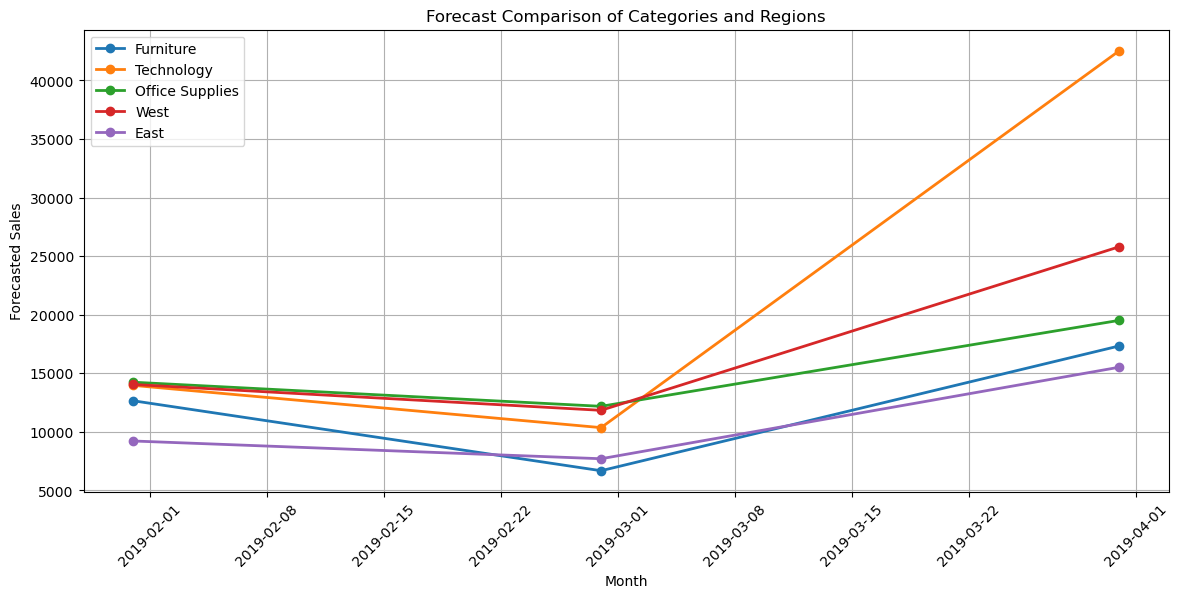

In [155]:
## Plot all the segments
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    furniture_forecast["ds"].tail(3),
    furniture_forecast["yhat"].tail(3),
    marker='o',
    linewidth=2,
    label="Furniture"
)

plt.plot(
    technology_forecast["ds"].tail(3),
    technology_forecast["yhat"].tail(3),
    marker='o',
    linewidth=2,
    label="Technology"
)

plt.plot(
    office_forecast["ds"].tail(3),
    office_forecast["yhat"].tail(3),
    marker='o',
    linewidth=2,
    label="Office Supplies"
)

plt.plot(
    west_forecast["ds"].tail(3),
    west_forecast["yhat"].tail(3),
    marker='o',
    linewidth=2,
    label="West"
)

plt.plot(
    east_forecast["ds"].tail(3),
    east_forecast["yhat"].tail(3),
    marker='o',
    linewidth=2,
    label="East"
)

plt.title("Forecast Comparison of Categories and Regions")
plt.xlabel("Month")
plt.ylabel("Forecasted Sales")
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
# plt.savefig("charts/3-months forecast of all 5  segment.png",dpi=300,bbox_inches="tight")
plt.show()

In [156]:
## Identify the sstrongest growth
highest_segment = forecast_summary.loc[
    forecast_summary["Month 3"].idxmax()
]

print(highest_segment)

Segment      Technology
Month 1    13971.169554
Month 2     10362.07956
Month 3    42537.162717
Name: 1, dtype: object


## Business Insights
#### Based on the Prophet forecasting results, the Technology category shows the strongest projected growth over the next three months, with the highest forecasted sales. Among the regions, the West region demonstrates stronger growth than the East region. This suggests that inventory planning and business strategies should prioritise these high-growth segments.

# Anomaly Detection in Sales Data

In [157]:
from sklearn.ensemble import IsolationForest

In [158]:
## convert daily sales data to weekly sales data
weekly_sales = (
    df.groupby(pd.Grouper(key='Order Date', freq='W'))['Sales']
      .sum()
      .reset_index()
)

In [159]:
weekly_sales.columns = ['Week', 'Sales']

In [160]:
weekly_sales.head()

,Week,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


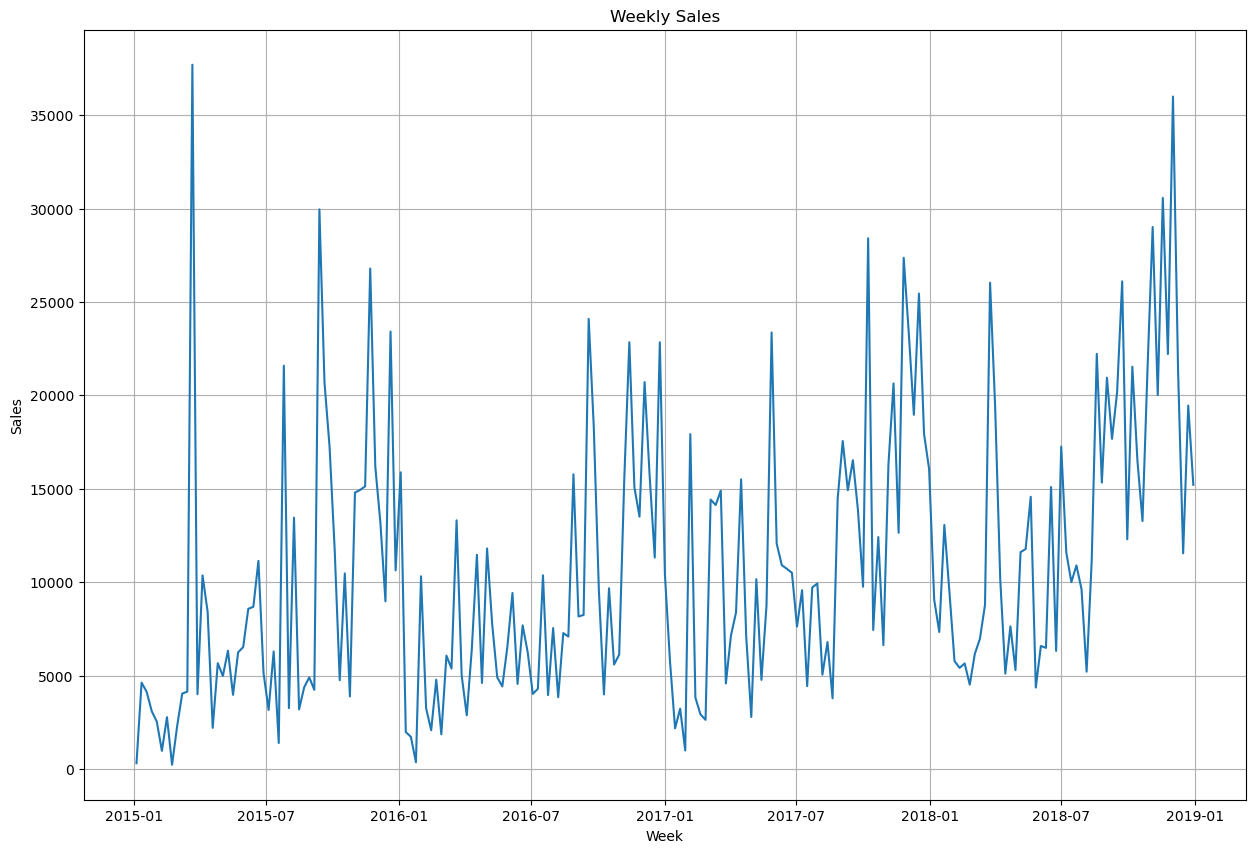

In [161]:
## Plotting weekly sales
plt.figure(figsize=(15,10))

plt.plot(
    weekly_sales['Week'],
    weekly_sales['Sales']
)

plt.title("Weekly Sales")
plt.xlabel("Week")
plt.ylabel("Sales")
plt.grid(True)
# plt.savefig("charts/baseline visualization to detect weekly anomalies.png",dpi=300,bbox_inches="tight")
plt.show()

In [162]:
## Train the model
X = weekly_sales[['Sales']]

In [163]:
iso_model = IsolationForest(

    contamination=0.05,

    random_state=42

)

iso_model.fit(X)

,n_estimators,100
,max_samples,'auto'
,contamination,0.05
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [164]:
joblib.dump(iso_model, "models/isolation_forest.pkl")

['models/isolation_forest.pkl']

In [165]:
weekly_sales['Isolation_Label'] = iso_model.predict(X)

In [166]:
weekly_sales['Isolation_Label']

0     -1
1      1
2      1
3      1
4      1
      ..
204   -1
205    1
206    1
207    1
208    1
Name: Isolation_Label, Length: 209, dtype: int64

In [167]:
## Extraxt weekly anomalies
iso_anomalies = weekly_sales[
    weekly_sales['Isolation_Label'] == -1
]

In [168]:
iso_anomalies

,Week,Sales,Isolation_Label
0,2015-01-04,304.508,-1
7,2015-02-22,224.912,-1
11,2015-03-22,37703.665,-1
36,2015-09-13,29959.137,-1
55,2016-01-24,358.522,-1
144,2017-10-08,28412.098,-1
151,2017-11-26,27367.716,-1
154,2017-12-17,25449.800,-1
200,2018-11-04,29017.467,-1
202,2018-11-18,30572.447,-1


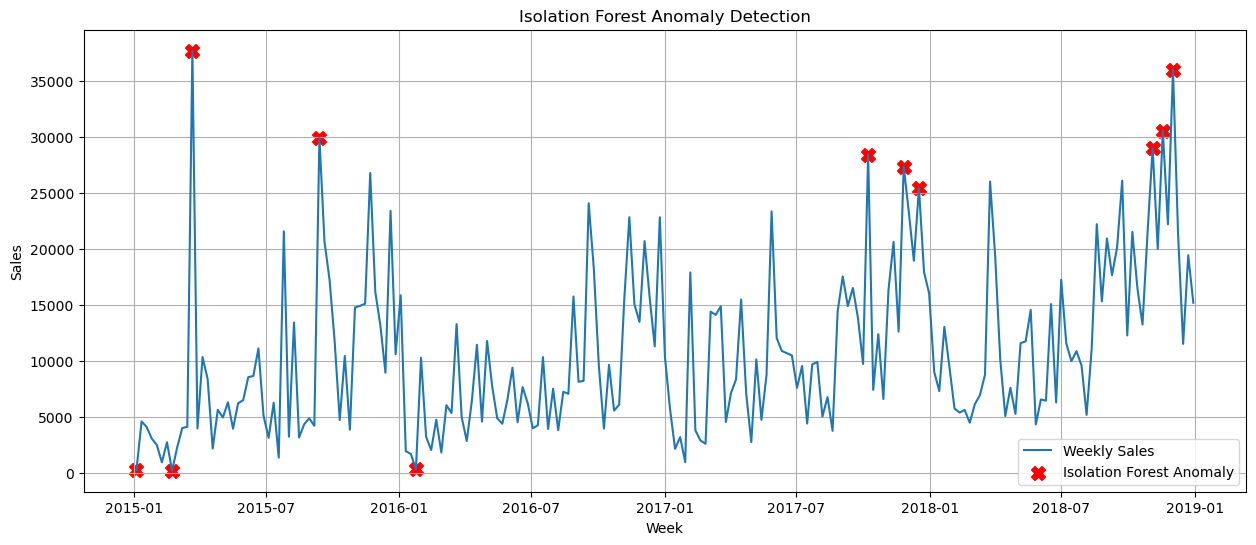

In [169]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales['Week'],
    weekly_sales['Sales'],
    label='Weekly Sales'
)

plt.scatter(
    iso_anomalies['Week'],
    iso_anomalies['Sales'],
    color='red',
    s=100,
    marker='X',
    label='Isolation Forest Anomaly'
)

plt.title("Isolation Forest Anomaly Detection")

plt.xlabel("Week")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)
# plt.savefig("charts/IsolationForest Anomaly plotting.png",dpi=300,bbox_inches="tight")
plt.show()

### Z-score based Anomaly Detection

In [170]:
weekly_sales['RollingMean'] = (
    weekly_sales['Sales']
    .rolling(window=8)
    .mean()
)

In [171]:
weekly_sales['RollingStd'] = (
    weekly_sales['Sales']
    .rolling(window=8)
    .std()
)

In [172]:
weekly_sales['ZScore'] = (
  weekly_sales['Sales']-weekly_sales['RollingMean']
    ) / weekly_sales['RollingStd']

In [173]:
weekly_sales['Z_Anomaly'] = (
    abs(weekly_sales['ZScore']) > 2
)

In [174]:
zscore_anomalies = weekly_sales[
    weekly_sales['Z_Anomaly']
]

In [175]:
zscore_anomalies

,Week,Sales,Isolation_Label,RollingMean,RollingStd,ZScore,Z_Anomaly
11,2015-03-22,37703.665,-1,6832.006500,12546.138409,2.460650,True
29,2015-07-26,21590.080,1,8245.428325,6246.129535,2.136467,True
86,2016-08-28,15773.478,1,7515.302525,4020.682890,2.053924,True
89,2016-09-18,24095.960,1,10251.475400,6524.009519,2.122082,True
125,2017-05-28,23367.662,1,10104.115375,6556.772342,2.022877,True
168,2018-03-25,26029.904,1,8660.308925,7131.467537,2.435627,True


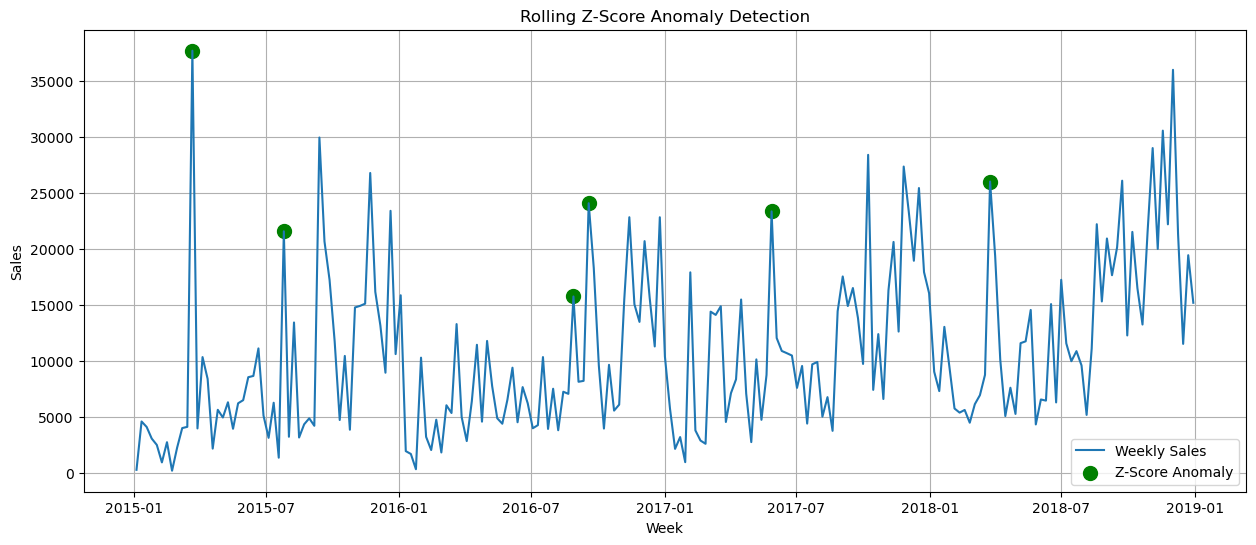

In [176]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales['Week'],
    weekly_sales['Sales'],
    label='Weekly Sales'
)

plt.scatter(
    zscore_anomalies['Week'],
    zscore_anomalies['Sales'],
    color='green',
    s=100,
    marker='o',
    label='Z-Score Anomaly'
)

plt.title("Rolling Z-Score Anomaly Detection")

plt.xlabel("Week")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)
# plt.savefig("charts/Z-score based Anomaly plotting.png",dpi=300,bbox_inches="tight")
plt.show()

### Compare both Method


In [177]:
comparison = weekly_sales[[
    'Week',
    'Sales',
    'Isolation_Label',
    'Z_Anomaly'
]]

comparison

,Week,Sales,Isolation_Label,Z_Anomaly
0,2015-01-04,304.5080,-1,False
1,2015-01-11,4619.1080,1,False
2,2015-01-18,4130.5330,1,False
3,2015-01-25,3092.5440,1,False
4,2015-02-01,2527.9140,1,False
...,...,...,...,...
204,2018-12-02,35998.9000,-1,False
205,2018-12-09,21332.2110,1,False
206,2018-12-16,11542.8340,1,False
207,2018-12-23,19457.0680,1,False


In [178]:
print("Isolation Forest Anomalies:")

print(len(iso_anomalies))

print()

print("Z-Score Anomalies:")

print(len(zscore_anomalies))

Isolation Forest Anomalies:
11

Z-Score Anomalies:
6


In [180]:
comparison.to_csv(
    "data/Anomaly_Comparison.csv",
    index=False
)

### Business Insights

### Isolation Forest
#### Isolation Forest detected several unusually high and low sales weeks. These anomalies may correspond to festive sales, promotional campaigns, clearance events, or unexpected drops due to supply chain issues or holidays.

### Z-Score
#### The rolling Z-Score method identified weeks where sales deviated by more than two standard deviations from the recent eight-week average. These represent statistically significant changes in weekly sales.

### Comparison:
#### Both methods identified some of the same unusual weeks, particularly large sales spikes. However, Isolation Forest also detected anomalies based on overall data distribution, while the rolling Z-Score method focused on deviations from recent historical behavior. This indicates that the two methods complement each other and may detect different types of anomalies

# Product Demand Segmentation using Clustering


In [181]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [182]:
## create monthly sales dataset
monthly_sales = (
    df.groupby(
        [
            "Sub-Category",
            pd.Grouper(key="Order Date", freq="ME")
        ]
    )["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,Sub-Category,Order Date,Sales
0,Accessories,2015-01-31,827.890
1,Accessories,2015-02-28,1120.990
2,Accessories,2015-03-31,957.734
3,Accessories,2015-04-30,2323.700
4,Accessories,2015-05-31,695.490


In [183]:
## calculate total sales volume
total_sales = (
    monthly_sales
    .groupby("Sub-Category")["Sales"]
    .sum()
    .reset_index(name="TotalSales")
)

total_sales.head()

,Sub-Category,TotalSales
0,Accessories,163881.6900
1,Appliances,104075.4630
2,Art,26697.3700
3,Binders,200028.7850
4,Bookcases,109408.2987


In [184]:
## calculate slaes volatility
volatility = (
    monthly_sales
    .groupby("Sub-Category")["Sales"]
    .std()
    .reset_index(name="Volatility")
)

volatility.head()

,Sub-Category,Volatility
0,Accessories,2578.699118
1,Appliances,1820.970554
2,Art,330.698732
3,Binders,3848.223648
4,Bookcases,2080.890675


In [185]:
## calculate average Order value
average_order = (
    df.groupby("Sub-Category")["Sales"]
    .mean()
    .reset_index(name="AverageOrderValue")
)

average_order.head()

,Sub-Category,AverageOrderValue
0,Accessories,217.349721
1,Appliances,227.239002
2,Art,34.052768
3,Binders,134.067550
4,Bookcases,486.259105


In [186]:
# calculate year over year growth
monthly_sales["Year"] = monthly_sales["Order Date"].dt.year

In [187]:
# yearly sales
yearly_sales = (
    monthly_sales
    .groupby(["Sub-Category","Year"])["Sales"]
    .sum()
    .reset_index()
)

In [188]:
## pivot the table
pivot = yearly_sales.pivot(
    index="Sub-Category",
    columns="Year",
    values="Sales"
)

In [189]:
pivot

Year,2015,2016,2017,2018
Sub-Category,,,,
Accessories,23766.3960,40443.9700,41635.3840,58035.9400
Appliances,15160.7150,23228.1790,26016.7870,39669.7820
Art,5897.5340,6091.6360,5882.5680,8825.6320
Binders,43263.2670,36049.7460,48994.5170,71721.2550
Bookcases,20036.6776,33071.8749,26275.4665,30024.2797
Chairs,77046.4400,69939.4730,81930.3450,93191.2730
Copiers,10849.7820,26179.4500,46319.4740,62899.3880
Envelopes,3844.5900,4448.2180,4456.6640,3376.5340
Fasteners,655.3880,545.2240,946.2740,855.0740


In [190]:
## calculate growth
growth = (
    (pivot.iloc[:,-1] - pivot.iloc[:,0])
    /
    pivot.iloc[:,0]
) * 100

growth = growth.reset_index()

growth.columns = [
    "Sub-Category",
    "GrowthRate"
]

In [191]:
# Merge all features
features = (
    total_sales
    .merge(volatility,on="Sub-Category")
    .merge(average_order,on="Sub-Category")
    .merge(growth,on="Sub-Category")
)

features

,Sub-Category,TotalSales,Volatility,AverageOrderValue,GrowthRate
0,Accessories,163881.6900,2578.699118,217.349721,144.193272
1,Appliances,104075.4630,1820.970554,227.239002,161.661683
2,Art,26697.3700,330.698732,34.052768,49.649531
3,Binders,200028.7850,3848.223648,134.067550,65.778638
4,Bookcases,109408.2987,2080.890675,486.259105,49.846598
5,Chairs,322107.5310,4387.620811,531.530579,20.954677
6,Copiers,146248.0940,5500.774391,2215.880212,479.729510
7,Envelopes,16126.0060,228.224872,65.287474,-12.174406
8,Fasteners,3001.9600,48.742229,14.027850,30.468364
9,Furnishings,89212.0180,1360.017867,95.823865,106.824969


In [192]:
## Handle missing values
features.fillna(0, inplace=True)

In [193]:
## create Feature matrix
X = features[[
    "TotalSales",
    "GrowthRate",
    "Volatility",
    "AverageOrderValue"
]]

In [194]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [195]:
joblib.dump(scaler, "models/scaler.pkl")

['models/scaler.pkl']

In [196]:
X_scaled

array([[ 0.31902423,  0.59920006,  0.08741487, -0.3612534 ],
       [-0.28908444,  0.75548869, -0.34385847, -0.34437149],
       [-1.07586353, -0.24667604, -1.19207052, -0.67415814],
       [ 0.68656726, -0.10237007,  0.80998508, -0.50342372],
       [-0.23486026, -0.2449129 , -0.19592077,  0.09779961],
       [ 1.92786181, -0.50340685,  1.1169916 ,  0.17508217],
       [ 0.13972613,  3.60121886,  1.75056078,  3.05042167],
       [-1.18335298, -0.7998104 , -1.25039516, -0.62083763],
       [-1.31679805, -0.41828858, -1.35255058, -0.70834251],
       [-0.44021569,  0.26486852, -0.60621706, -0.5687092 ],
       [-1.22177046, -0.36814096, -1.25310078, -0.67324535],
       [ 0.57685316, -0.95744378,  1.80905986,  2.07682128],
       [-0.56707056,  0.12559811, -0.79608708, -0.63423876],
       [ 1.97239927, -0.37275548,  0.94367703, -0.09532422],
       [ 0.86705217, -0.34762802,  0.2454443 , -0.28491398],
       [-0.87532104, -0.59000095, -0.22767826, -0.3016169 ],
       [ 0.71485299, -0.

In [197]:
## Elbow Method
inertia = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

O:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
O:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
O:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
O:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than availabl

In [198]:
inertia

[38.26864003158943,
 16.331256297725883,
 10.278619199527009,
 5.943404552709805,
 3.7228469408751987,
 2.463981900134942,
 1.596914274216141,
 1.1819329792208941,
 0.8370240480383706]

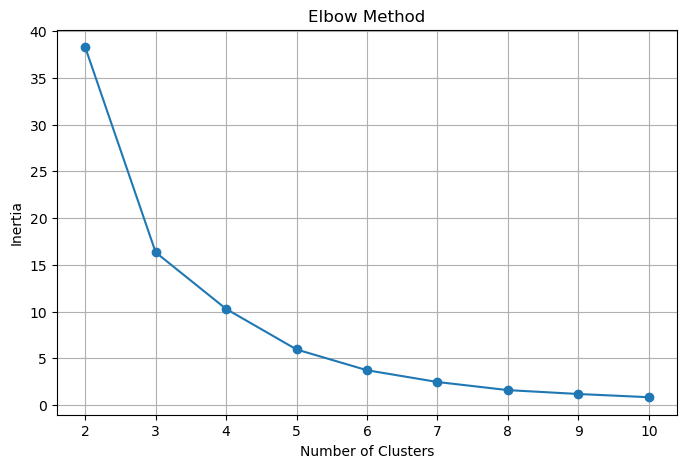

In [199]:
## plot elbow curve
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.grid(True)
# plt.savefig("charts/Elbow Curve.png",dpi=300,bbox_inches="tight")
plt.show()

In [200]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

features["Cluster"] = kmeans.fit_predict(X_scaled)

O:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [201]:
joblib.dump(kmeans, "models/kmeans.pkl")

['models/kmeans.pkl']

In [202]:
features.sort_values("Cluster")

,Sub-Category,TotalSales,Volatility,AverageOrderValue,GrowthRate,Cluster
0,Accessories,163881.6900,2578.699118,217.349721,144.193272,0
3,Binders,200028.7850,3848.223648,134.067550,65.778638,0
5,Chairs,322107.5310,4387.620811,531.530579,20.954677,0
14,Storage,217779.1020,2856.349976,262.068715,38.366108,0
13,Phones,326487.6980,4083.114611,373.128798,35.557607,0
16,Tables,202810.6280,3224.082504,645.893720,33.078016,0
6,Copiers,146248.0940,5500.774391,2215.880212,479.729510,1
2,Art,26697.3700,330.698732,34.052768,49.649531,2
7,Envelopes,16126.0060,228.224872,65.287474,-12.174406,2
4,Bookcases,109408.2987,2080.890675,486.259105,49.846598,2


In [203]:
## Perform PCA 
pca = PCA(
    n_components=2,
    random_state=42
)

components = pca.fit_transform(X_scaled)

In [204]:
joblib.dump(pca, "models/pca.pkl")

['models/pca.pkl']

In [205]:
features["PC1"] = components[:,0]

features["PC2"] = components[:,1]

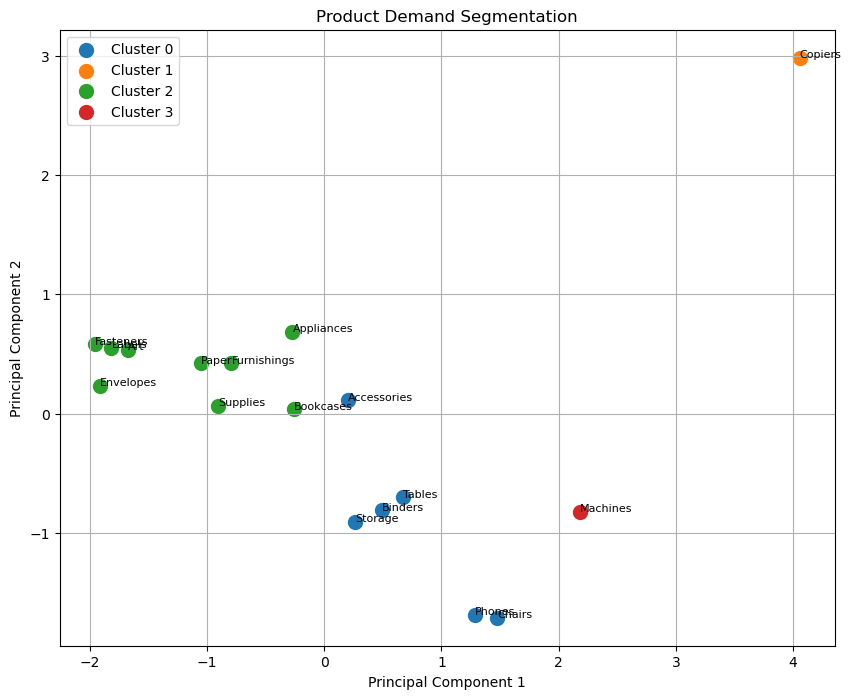

In [206]:
plt.figure(figsize=(10,8))

for cluster in sorted(features["Cluster"].unique()):

    subset = features[
        features["Cluster"] == cluster
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"Cluster {cluster}",
        s=100
    )

for _, row in features.iterrows():

    plt.text(
        row["PC1"],
        row["PC2"],
        row["Sub-Category"],
        fontsize=8
    )

plt.title("Product Demand Segmentation")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.legend()

plt.grid(True)
plt.savefig("charts/PCA.png",dpi=300,bbox_inches="tight")
plt.show()

In [207]:
cluster_summary = (
    features
    .groupby("Cluster")[
        [
            "TotalSales",
            "GrowthRate",
            "Volatility",
            "AverageOrderValue"
        ]
    ]
    .mean()
)

cluster_summary

,TotalSales,GrowthRate,Volatility,AverageOrderValue
Cluster,,,,
0,238849.239000,56.321387,3496.348445,360.673181
1,146248.094000,479.729510,5500.774391,2215.880212
2,53780.583744,58.320537,1016.059418,140.777669
3,189238.631000,-29.793120,5603.554747,1645.553313


In [208]:
## Adding Cluster lables
cluster_names = {
    0:"High Volume, Stable Demand",
    1:"Low Volume, High Volatility",
    2:"Growing Demand",
    3:"Declining Demand"
}

features["ClusterLabel"] = features["Cluster"].map(cluster_names)

In [209]:
features

,Sub-Category,TotalSales,Volatility,AverageOrderValue,GrowthRate,Cluster,PC1,PC2,ClusterLabel
0,Accessories,163881.6900,2578.699118,217.349721,144.193272,0,0.204163,0.111128,"High Volume, Stable Demand"
1,Appliances,104075.4630,1820.970554,227.239002,161.661683,2,-0.270756,0.687101,Growing Demand
2,Art,26697.3700,330.698732,34.052768,49.649531,2,-1.670807,0.536293,Growing Demand
3,Binders,200028.7850,3848.223648,134.067550,65.778638,0,0.490948,-0.809601,"High Volume, Stable Demand"
4,Bookcases,109408.2987,2080.890675,486.259105,49.846598,2,-0.255908,0.038047,Growing Demand
5,Chairs,322107.5310,4387.620811,531.530579,20.954677,0,1.476673,-1.709981,"High Volume, Stable Demand"
6,Copiers,146248.0940,5500.774391,2215.880212,479.729510,1,4.054959,2.982005,"Low Volume, High Volatility"
7,Envelopes,16126.0060,228.224872,65.287474,-12.174406,2,-1.915842,0.235171,Growing Demand
8,Fasteners,3001.9600,48.742229,14.027850,30.468364,2,-1.955575,0.583995,Growing Demand
9,Furnishings,89212.0180,1360.017867,95.823865,106.824969,2,-0.791828,0.420925,Growing Demand


## Shocking Strategy 


#### 1. High Volume, Stable Demand: Maintain high inventory levels with frequent replenishment to avoid stockouts.
#### 2. Low Volume, High Volatility: Keep limited stock and use demand-driven replenishment to reduce inventory risk.
#### 3. Growing Demand: Increase inventory gradually and monitor demand closely to support future growth.
#### 4. Declining Demand: Reduce stock levels, avoid over-ordering, and consider promotional strategies to clear inventory

In [210]:
features.to_csv("data/clusters.csv",index=False)

## Save the important product and Region csv files for streamlit Dashboard

In [211]:
# Categories
furniture_df = df[df["Category"] == "Furniture"].copy()
technology_df = df[df["Category"] == "Technology"].copy()
office_df = df[df["Category"] == "Office Supplies"].copy()

# Regions
west_df = df[df["Region"] == "West"].copy()
east_df = df[df["Region"] == "East"].copy()

In [213]:


def prophet_forecast(data):

    monthly = (
        data.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
        .sum()
        .reset_index()
    )

    monthly.columns = ["ds", "y"]

    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False
    )

    model.fit(monthly)

    future = model.make_future_dataframe(
        periods=3,
        freq="ME"
    )

    forecast = model.predict(future)

    return forecast

In [214]:
furniture_forecast = prophet_forecast(furniture_df)

technology_forecast = prophet_forecast(technology_df)

office_forecast = prophet_forecast(office_df)

west_forecast = prophet_forecast(west_df)

east_forecast = prophet_forecast(east_df)

11:12:44 - cmdstanpy - INFO - Chain [1] start processing
11:12:44 - cmdstanpy - INFO - Chain [1] done processing
11:12:44 - cmdstanpy - INFO - Chain [1] start processing
11:12:45 - cmdstanpy - INFO - Chain [1] done processing
11:12:45 - cmdstanpy - INFO - Chain [1] start processing
11:12:45 - cmdstanpy - INFO - Chain [1] done processing
11:12:45 - cmdstanpy - INFO - Chain [1] start processing
11:12:45 - cmdstanpy - INFO - Chain [1] done processing
11:12:46 - cmdstanpy - INFO - Chain [1] start processing
11:12:46 - cmdstanpy - INFO - Chain [1] done processing


In [215]:
furniture_forecast.tail(3)[
    ["ds","yhat","yhat_lower","yhat_upper"]
].to_csv(
    "data/furniture_forecast.csv",
    index=False
)

In [216]:
technology_forecast.tail(3)[
    ["ds","yhat","yhat_lower","yhat_upper"]
].to_csv(
    "data/technology_forecast.csv",
    index=False
)

In [217]:
office_forecast.tail(3)[
    ["ds","yhat","yhat_lower","yhat_upper"]
].to_csv(
    "data/office_forecast.csv",
    index=False
)

In [218]:
west_forecast.tail(3)[
    ["ds","yhat","yhat_lower","yhat_upper"]
].to_csv(
    "data/west_forecast.csv",
    index=False
)

In [219]:
east_forecast.tail(3)[
    ["ds","yhat","yhat_lower","yhat_upper"]
].to_csv(
    "data/east_forecast.csv",
    index=False
)